# Experiment 3 — REVIEWER-FIXED FINAL FULL RUN (PaliGemma 620 + Qwen 620)

This is the **final clean full-run notebook** for Experiment 3.

## Frozen sample design
- **620 unique synthetic scenes**
- Object counts **2–32 inclusive** (31 count levels)
- **20 independent scenes per object count**
- The **same 620 scenes** are run through:
  - `google/paligemma2-3b-pt-448`
  - `Qwen/Qwen2.5-VL-3B-Instruct`
- Every scene is evaluated under the same prompt texts within a model comparison.

## Primary causal question
Does **linguistic relevance/content**, holding prompt length and lexical domain as tightly controlled as possible, reorganize the geometry of image-token representations inside the VLM language backbone?

## Final conditions
| Condition | Meaning |
|---|---|
| C2 | minimal / template-only baseline |
| C3 | long vocabulary-matched irrelevant A |
| C4 | short vocabulary-matched irrelevant A |
| C5 | short relevant |
| C6 | long relevant |
| C7 | short vocabulary-matched irrelevant B — negative/noise-floor control |
| C8 | long vocabulary-matched irrelevant B — negative/noise-floor control |

**Important change from the pilot:** the final run does **not** use abstract event-domain irrelevant prompts as the primary irrelevant condition.  
C4/C3 now use the **same color/shape/spatial vocabulary** as C5/C6 but refer to objects absent from the current scene. This removes the strongest lexical-domain confound identified in the audit. Pilot and final-run effect estimates should therefore **not be pooled**.

## Quality controls added before inference
- exact short/long token-length matching under **both PaliGemma and Qwen tokenizers**
- the **same prompt text** used on both architectures
- multiple repeated prompt templates, balanced across scenes
- seeded non-maximal relevant-pair selection across spatial-separation strata
- second matched irrelevant prompt pair (C7/C8) as a within-category noise floor
- bounded spatial jitter / neutral-background variation in the synthetic generator
- layer-0 embedding floor
- Qwen image-first causal null
- Procrustes identity-permutation null
- image-level bootstrap CIs and paired effect sizes
- object-count sign consistency and moderation analyses
- repeated-measures mixed models
- paired cross-model replication on the **same 620 scenes**
- intrinsic-dimension analysis with **constant sample size across object-count cells**

## Interpretation discipline
The main statistical unit for ΔRDM / Procrustes / crowding is the **image**.  
Tokens and layers are never treated as independent samples.  
Intrinsic dimensionality is reported at the **object-count-cell level**, with repeated constant-size object subsampling.

Run this notebook **top to bottom on a fresh H100 instance**. It checkpoints every completed image and is safe to resume while the Lambda instance still exists.


### Reviewer-fixed interpretation
The primary intervention should be described narrowly as **present-referent / grounded prompt vs. absent-referent matched prompt**, not as abstract “relevance holding semantics constant.” A relevant-but-false control would be needed to fully separate referential success from truth value; that is not silently claimed here.

### Confirmatory inference
Exactly three confirmatory image-level tests per model are Holm-corrected:
1. direct signed ΔRDM, C5−C4;
2. excess signed ΔRDM over the C4−C7 matched irrelevant lexical-change noise floor;
3. mentioned-vs-unmentioned specificity double difference.

Procrustes, crowding, count moderation, and long-prompt replication are secondary. Intrinsic dimensionality and anisotropy are exploratory.


## 1. Hugging Face authentication


In [1]:
from getpass import getpass
HF_TOKEN = getpass("Hugging Face token (input hidden): ").strip()
if not HF_TOKEN:
    raise RuntimeError("HF token is required for the gated PaliGemma checkpoint.")


Hugging Face token (input hidden):  ········


## 2. Install dependencies


In [2]:
!pip install -q -U \
    "numpy==1.26.4" \
    "transformers==4.57.2" \
    "accelerate>=1.5,<2" \
    "huggingface_hub>=0.30,<2" \
    "qwen-vl-utils>=0.0.10,<1" \
    "scikit-learn>=1.4,<2" \
    "scipy>=1.12,<2" \
    "statsmodels>=0.14,<1" \
    "openpyxl>=3.1,<4" \
    "matplotlib>=3.8,<4" \
    "pandas>=2.1,<3" \
    "psutil>=5.9,<8"


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
types-seaborn 0.13 requires pandas-stubs, which is not installed.


## 3. Lambda H100 preflight — local instance disk only


In [2]:
import os, shutil, subprocess
from pathlib import Path

print("Working directory:", os.getcwd())
print("Home:", Path.home())
subprocess.run(["nvidia-smi"], check=False)

disk = shutil.disk_usage(Path.home())
print(f"Local disk: {disk.total/2**30:.1f} GiB total; {disk.free/2**30:.1f} GiB free")

if disk.free < 150 * 2**30:
    raise RuntimeError(
        "Less than 150 GiB free. Stop before inference and inspect local disk."
    )

print("\nIMPORTANT: this notebook uses the instance's LOCAL disk.")
print("Do NOT terminate the Lambda instance until the result archive is downloaded.")


Working directory: /home/ubuntu
Home: /home/ubuntu
Fri Sep  4 20:32:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  |   00000000:06:00.0 Off |                    0 |
| N/A   31C    P0             50W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled

## 4. Imports and frozen configuration


In [3]:
import os
# PyTorch-only experiment: avoid importing Lambda Stack's system TensorFlow.
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"

import gc, hashlib, itertools, json, math, random, time, warnings, tarfile
from functools import lru_cache
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image, ImageDraw
from scipy import stats
from sklearn.neighbors import NearestNeighbors
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
import statsmodels.formula.api as smf
import transformers
import sklearn
import statsmodels
import PIL
import psutil

from huggingface_hub import model_info

from transformers import (
    AutoProcessor,
    PaliGemmaForConditionalGeneration,
    Qwen2_5_VLForConditionalGeneration,
)

SEED = 20260730
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

RUN_NAME = "experiment3_FINAL_REVIEWER_FIXED_620x620_seed20260730_v2"
ROOT = Path.home() / "ESSR" / RUN_NAME
DATA_DIR = ROOT / "synthetic_dataset"
IMAGES_DIR = DATA_DIR / "images"
LABELS_DIR = DATA_DIR / "label_maps"
MANIFEST_PATH = DATA_DIR / "manifest.jsonl"
PROMPTS_DIR = ROOT / "prompts"
SHARED_PROMPT_PATH = PROMPTS_DIR / "shared_prompts.jsonl"
VECTORS_DIR = ROOT / "vectors"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

for p in [
    DATA_DIR, IMAGES_DIR, LABELS_DIR, PROMPTS_DIR,
    VECTORS_DIR, RESULTS_DIR, FIGURES_DIR
]:
    p.mkdir(parents=True, exist_ok=True)

PRIMARY_MODEL_ID = "google/paligemma2-3b-pt-448"
SECONDARY_MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"

CANVAS_SIZE = 448
OBJECT_COUNTS = list(range(2, 33))
N_IMAGES_PER_COUNT = 20
EXPECTED_IMAGES = len(OBJECT_COUNTS) * N_IMAGES_PER_COUNT  # 620

# Qwen is now a FULL shared-scene replication, not a reduced check.
QWEN_COUNTS = OBJECT_COUNTS.copy()
QWEN_IMAGES_PER_COUNT = N_IMAGES_PER_COUNT

PRIMARY_CONDITIONS = ["c2", "c3", "c4", "c5", "c6"]
AUX_CONTROL_CONDITIONS = ["c7", "c8"]
CONDITIONS = PRIMARY_CONDITIONS + AUX_CONTROL_CONDITIONS

CONDITION_LABELS = {
    "c2": "minimal/template baseline",
    "c3": "long matched irrelevant A",
    "c4": "short matched irrelevant A",
    "c5": "short relevant",
    "c6": "long relevant",
    "c7": "short matched irrelevant B",
    "c8": "long matched irrelevant B",
}

# Intrinsic-dimension design:
# exactly 2 sampled objects/image × 20 images = 40 vectors per count cell,
# repeated to reduce dependence on which objects were sampled.
ID_OBJECTS_PER_IMAGE = 2
ID_REPEATS = 20
PRIMARY_ID_K = 5
ID_K_VALUES = [3, 5, 7, 10]
ID_POOL_N = ID_OBJECTS_PER_IMAGE * N_IMAGES_PER_COUNT
assert ID_POOL_N == 40

BOOTSTRAP_RESAMPLES = 10_000
EFFECT_SIZE_REFERENCE = 0.20  # interpretation aid, NOT a hard acceptance criterion

RUN_PALIGEMMA = True
RUN_QWEN = True
RUN_QWEN_IMAGE_FIRST_NULL = True
RESUME_CURRENT_RUN = True
REQUIRE_BFLOAT16 = True
ATTN_IMPLEMENTATION = "eager"

QWEN_NULL_COUNTS = [2, 8, 16, 24, 32]
QWEN_NULL_IMAGES_PER_COUNT = 3
NULL_TOLERANCE = 1e-4

PROCRUSTES_NULL_COUNTS = [4, 8, 16, 24, 32]
PROCRUSTES_NULL_IMAGES_PER_COUNT = 4
PROCRUSTES_NULL_PERMUTATIONS = 50

print("Run root:", ROOT)
print("Unique scenes:", EXPECTED_IMAGES)
print("PaliGemma scenes:", EXPECTED_IMAGES)
print("Qwen scenes:", EXPECTED_IMAGES)
print("Conditions:", CONDITIONS)


/home/ubuntu/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/ubuntu/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Run root: /home/ubuntu/ESSR/experiment3_FINAL_REVIEWER_FIXED_620x620_seed20260730_v2
Unique scenes: 620
PaliGemma scenes: 620
Qwen scenes: 620
Conditions: ['c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8']


In [4]:
# Lambda Stack compatibility gate
from packaging.version import Version
print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)

if Version(np.__version__) >= Version("2.0.0"):
    raise RuntimeError(
        "NumPy 2.x is active. This Lambda image contains extensions compiled "
        "against NumPy 1.x. Restart the kernel after installing numpy==1.26.4."
    )

# Verify PyTorch<->NumPy bridge, which failed in the previous run.
_probe_np = np.asarray([1.0, 2.0], dtype=np.float32)
_probe_t = torch.from_numpy(_probe_np)
assert np.allclose(_probe_t.cpu().numpy(), _probe_np)

print("NUMPY / PYTORCH COMPATIBILITY CHECK PASSED.")


NumPy: 1.26.4
PyTorch: 2.7.0
Transformers: 4.57.2
NUMPY / PYTORCH COMPATIBILITY CHECK PASSED.


In [5]:
# Freeze exact Hugging Face checkpoint revisions for reproducibility.
REVISION_PATH = ROOT / "model_revisions.json"

if REVISION_PATH.exists():
    MODEL_REVISIONS = json.loads(REVISION_PATH.read_text(encoding="utf-8"))
else:
    MODEL_REVISIONS = {
        PRIMARY_MODEL_ID: model_info(PRIMARY_MODEL_ID, token=HF_TOKEN).sha,
        SECONDARY_MODEL_ID: model_info(SECONDARY_MODEL_ID, token=HF_TOKEN).sha,
    }
    REVISION_PATH.write_text(
        json.dumps(MODEL_REVISIONS, indent=2),
        encoding="utf-8",
    )

PRIMARY_REVISION = MODEL_REVISIONS[PRIMARY_MODEL_ID]
SECONDARY_REVISION = MODEL_REVISIONS[SECONDARY_MODEL_ID]

ENVIRONMENT = {
    "transformers": transformers.__version__,
    "torch": torch.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn.__version__,
    "statsmodels": statsmodels.__version__,
    "pillow": PIL.__version__,
    "cuda": torch.version.cuda,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
}

print("Pinned Transformers:", transformers.__version__)
print("PaliGemma revision:", PRIMARY_REVISION)
print("Qwen revision:", SECONDARY_REVISION)
print("Environment:", json.dumps(ENVIRONMENT, indent=2))


Pinned Transformers: 4.57.2
PaliGemma revision: bd60523c1ff2b0020c11e68affe65ef0b2379cab
Qwen revision: 66285546d2b821cf421d4f5eb2576359d3770cd3
Environment: {
  "transformers": "4.57.2",
  "torch": "2.7.0",
  "numpy": "1.26.4",
  "pandas": "2.3.3",
  "sklearn": "1.9.0",
  "statsmodels": "0.15.0",
  "pillow": "10.2.0",
  "cuda": "12.8",
  "gpu": "NVIDIA A100-SXM4-40GB"
}


In [6]:
run_config = {
    "seed": SEED,
    "run_name": RUN_NAME,
    "canvas_size": CANVAS_SIZE,
    "object_counts": OBJECT_COUNTS,
    "images_per_count": N_IMAGES_PER_COUNT,
    "expected_unique_scenes": EXPECTED_IMAGES,
    "primary_model": PRIMARY_MODEL_ID,
    "secondary_model": SECONDARY_MODEL_ID,
    "qwen_full_shared_scene_replication": True,
    "conditions": CONDITIONS,
    "condition_labels": CONDITION_LABELS,
    "id_objects_per_image": ID_OBJECTS_PER_IMAGE,
    "id_repeats": ID_REPEATS,
    "primary_id_k": PRIMARY_ID_K,
    "id_k_values": ID_K_VALUES,
    "bootstrap_resamples": BOOTSTRAP_RESAMPLES,
    "attention_implementation": ATTN_IMPLEMENTATION,
    "model_revisions": MODEL_REVISIONS,
    "environment": ENVIRONMENT,
    "confirmatory_family": [
        "direct signed DeltaRDM C5-C4",
        "excess signed DeltaRDM over C4-C7 noise floor",
        "mentioned-vs-unmentioned specificity double difference",
    ],
    "methodological_note": (
        "Reviewer-fixed final run uses expanded stimulus support, relation-matched "
        "and descriptor-disjoint vocabulary-matched irrelevant controls. Pilot and final "
        "effect estimates must not be pooled."
    ),
}

config_path = ROOT / "run_config.json"
if config_path.exists():
    saved = json.loads(config_path.read_text(encoding="utf-8"))
    if saved != run_config:
        raise RuntimeError(
            "Existing run folder has a different configuration. "
            "Use a new RUN_NAME rather than mixing experiments."
        )
else:
    config_path.write_text(json.dumps(run_config, indent=2), encoding="utf-8")

print("Frozen configuration:", config_path)


Frozen configuration: /home/ubuntu/ESSR/experiment3_FINAL_REVIEWER_FIXED_620x620_seed20260730_v2/run_config.json


## 5. Checkpoint / resume utilities


In [7]:
PROGRESS_FILE = ROOT / "experiment3_progress.json"

def stable_int(*parts):
    payload = "|".join(map(str, parts)).encode()
    return int(hashlib.sha256(payload).hexdigest()[:16], 16)

def save_progress(stage, completed, total, elapsed_seconds=None):
    payload = {
        "stage": stage,
        "completed": int(completed),
        "total": int(total),
        "updated_unix": time.time(),
    }
    if elapsed_seconds is not None:
        payload["elapsed_seconds_this_session"] = float(elapsed_seconds)
    PROGRESS_FILE.write_text(json.dumps(payload, indent=2), encoding="utf-8")

def load_progress():
    if PROGRESS_FILE.exists():
        return json.loads(PROGRESS_FILE.read_text(encoding="utf-8"))
    return {}

def atomic_savez(path, **arrays):
    path = Path(path)
    tmp = path.with_suffix(".tmp.npz")
    np.savez(tmp, **arrays)  # uncompressed: faster and disk is abundant
    tmp.replace(path)

print("Progress file:", PROGRESS_FILE)


Progress file: /home/ubuntu/ESSR/experiment3_FINAL_REVIEWER_FIXED_620x620_seed20260730_v2/experiment3_progress.json


## 6. Generate 620 fresh synthetic scenes

Compared with the pilot grid, this generator preserves controlled non-overlap while adding:
- bounded position jitter,
- three neutral background levels,
- radius variation,
- randomized descriptors and occupied cells.

The bounded jitter is intentionally small enough that neighboring objects cannot overlap. This broadens the stimulus manifold without changing the controlled object-count manipulation.


In [8]:
COLOR_PALETTE = {
    "red": (220, 50, 47),
    "blue": (38, 111, 209),
    "green": (42, 161, 74),
    "yellow": (238, 190, 46),
    "purple": (130, 78, 185),
    "orange": (235, 112, 37),
    "cyan": (39, 174, 196),
    "pink": (224, 90, 151),
    "brown": (145, 92, 55),
    "teal": (34, 139, 131),
    "lime": (133, 187, 51),
    "navy": (44, 62, 120),
}

# Expanded support prevents the high-count stimulus manifold from collapsing:
# 12 colors x 6 shapes = 72 descriptors, versus a maximum of 32 objects.
SHAPES = ["circle", "square", "triangle", "diamond", "pentagon", "hexagon"]
DESCRIPTORS = [(c, s) for c in COLOR_PALETTE for s in SHAPES]
DESCRIPTOR_NAMES = [f"{c} {s}" for c, s in DESCRIPTORS]
assert len(DESCRIPTORS) == 72

# 49 candidate cells rather than 36. At n=32 this keeps much more scene diversity.
GRID_SIDE = 7
GRID_MARGIN = 32
GRID_STEP = (CANVAS_SIZE - 2 * GRID_MARGIN) / (GRID_SIDE - 1)
GRID_CENTERS = [
    (int(round(GRID_MARGIN + col * GRID_STEP)),
     int(round(GRID_MARGIN + row * GRID_STEP)))
    for row in range(GRID_SIDE)
    for col in range(GRID_SIDE)
]

LAYOUT_JITTERS = [0, 5, 10]
BACKGROUND_LEVELS = [240, 248, 255]
RADIUS_RANGE = (15, 19)

def draw_shape(draw_rgb, draw_labels, object_id, shape, color, center, radius):
    cx, cy = center
    bbox = [cx-radius, cy-radius, cx+radius, cy+radius]

    if shape == "circle":
        draw_rgb.ellipse(bbox, fill=color)
        draw_labels.ellipse(bbox, fill=object_id)
    elif shape == "square":
        draw_rgb.rectangle(bbox, fill=color)
        draw_labels.rectangle(bbox, fill=object_id)
    elif shape == "triangle":
        pts = [(cx, cy-radius), (cx-radius, cy+radius), (cx+radius, cy+radius)]
        draw_rgb.polygon(pts, fill=color)
        draw_labels.polygon(pts, fill=object_id)
    elif shape in ("diamond", "pentagon", "hexagon"):
        sides = {"diamond": 4, "pentagon": 5, "hexagon": 6}[shape]
        rotation = {"diamond": 0, "pentagon": -90, "hexagon": 0}[shape]
        draw_rgb.regular_polygon(
            (cx, cy, radius), sides, rotation=rotation, fill=color
        )
        draw_labels.regular_polygon(
            (cx, cy, radius), sides, rotation=rotation, fill=object_id
        )
    else:
        raise ValueError(shape)

    return [int(v) for v in bbox]

def generate_scene(object_count, image_index):
    scene_seed = SEED + object_count * 100_000 + image_index
    rng = random.Random(scene_seed)

    base_indices = rng.sample(range(len(GRID_CENTERS)), object_count)
    descriptors = rng.sample(DESCRIPTORS, object_count)

    layout_variant = image_index % len(LAYOUT_JITTERS)
    jitter_amp = LAYOUT_JITTERS[layout_variant]

    # Cross background and jitter rather than making them perfectly collinear.
    background_variant = (image_index // len(LAYOUT_JITTERS)) % len(BACKGROUND_LEVELS)
    background = BACKGROUND_LEVELS[background_variant]

    positions = []
    jitters = []
    for idx in base_indices:
        bx, by = GRID_CENTERS[idx]
        jx = rng.randint(-jitter_amp, jitter_amp) if jitter_amp else 0
        jy = rng.randint(-jitter_amp, jitter_amp) if jitter_amp else 0
        positions.append((bx + jx, by + jy))
        jitters.append((jx, jy))

    if len(positions) > 1:
        min_dist = min(
            math.dist(positions[a], positions[b])
            for a in range(len(positions))
            for b in range(a + 1, len(positions))
        )
        if min_dist <= 2 * RADIUS_RANGE[1]:
            raise RuntimeError(
                f"{object_count=} {image_index=}: possible overlap ({min_dist=:.2f})."
            )
    else:
        min_dist = float("nan")

    image = Image.new("RGB", (CANVAS_SIZE, CANVAS_SIZE), (background,) * 3)
    labels = Image.new("L", (CANVAS_SIZE, CANVAS_SIZE), 0)
    draw_rgb = ImageDraw.Draw(image)
    draw_labels = ImageDraw.Draw(labels)

    objects = []
    for object_id, ((color_name, shape), center, base_idx, jitter) in enumerate(
        zip(descriptors, positions, base_indices, jitters), start=1
    ):
        radius = rng.randint(*RADIUS_RANGE)
        bbox = draw_shape(
            draw_rgb, draw_labels, object_id, shape,
            COLOR_PALETTE[color_name], center, radius
        )
        objects.append({
            "object_id": object_id,
            "color": color_name,
            "shape": shape,
            "name": f"{color_name} {shape}",
            "bbox": bbox,
            "centroid_px": [int(center[0]), int(center[1])],
            "centroid": [center[0] / CANVAS_SIZE, center[1] / CANVAS_SIZE],
            "base_grid_index": int(base_idx),
            "jitter_px": [int(jitter[0]), int(jitter[1])],
            "radius_px": int(radius),
        })

    image_id = f"n{object_count:02d}_i{image_index:03d}"
    metadata = {
        "scene_seed": scene_seed,
        "layout_variant": int(layout_variant),
        "background_variant": int(background_variant),
        "jitter_amp": int(jitter_amp),
        "background_level": int(background),
        "min_center_distance_px": None if not np.isfinite(min_dist) else float(min_dist),
    }
    return image_id, image, labels, objects, metadata


In [9]:
if MANIFEST_PATH.exists() and RESUME_CURRENT_RUN:
    manifest = [
        json.loads(line)
        for line in MANIFEST_PATH.read_text(encoding="utf-8").splitlines()
        if line.strip()
    ]
    if len(manifest) != EXPECTED_IMAGES:
        raise RuntimeError("Existing manifest has wrong size. Use a fresh RUN_NAME.")
else:
    manifest = []
    for object_count in OBJECT_COUNTS:
        for image_index in range(N_IMAGES_PER_COUNT):
            image_id, image, labels, objects, meta = generate_scene(
                object_count, image_index
            )
            image_filename = f"{image_id}.png"
            label_filename = f"{image_id}_labels.png"
            image.save(IMAGES_DIR / image_filename)
            labels.save(LABELS_DIR / label_filename)

            manifest.append({
                "image_id": image_id,
                "object_count": object_count,
                "image_index": image_index,
                "image_filename": image_filename,
                "label_filename": label_filename,
                "objects": objects,
                **meta,
            })

    with MANIFEST_PATH.open("w", encoding="utf-8") as f:
        for record in manifest:
            f.write(json.dumps(record) + "\n")

assert len(manifest) == EXPECTED_IMAGES
assert sorted({r["object_count"] for r in manifest}) == OBJECT_COUNTS
assert all(
    sum(r["object_count"] == c for r in manifest) == N_IMAGES_PER_COUNT
    for c in OBJECT_COUNTS
)
print("Synthetic images:", len(manifest))
print("Counts:", min(OBJECT_COUNTS), "to", max(OBJECT_COUNTS))


Synthetic images: 620
Counts: 2 to 32


### 6.1 Dataset integrity checks


In [10]:
integrity_rows = []

for record in manifest:
    image = Image.open(IMAGES_DIR / record["image_filename"]).convert("RGB")
    labels = np.asarray(Image.open(LABELS_DIR / record["label_filename"]))

    expected_ids = set(range(1, record["object_count"] + 1))
    actual_ids = set(np.unique(labels).tolist()) - {0}
    object_pixels = [(labels == oid).sum() for oid in sorted(expected_ids)]

    integrity_rows.append({
        "image_id": record["image_id"],
        "object_count": record["object_count"],
        "layout_variant": record["layout_variant"],
        "background_level": record["background_level"],
        "size_ok": image.size == (CANVAS_SIZE, CANVAS_SIZE),
        "label_ids_ok": actual_ids == expected_ids,
        "unique_descriptors_ok": len({o["name"] for o in record["objects"]}) == record["object_count"],
        "min_object_pixels": int(min(object_pixels)),
    })

dataset_integrity = pd.DataFrame(integrity_rows)

assert dataset_integrity["size_ok"].all()
assert dataset_integrity["label_ids_ok"].all()
assert dataset_integrity["unique_descriptors_ok"].all()
assert dataset_integrity["min_object_pixels"].min() > 0

dataset_integrity.to_csv(RESULTS_DIR / "dataset_integrity.csv", index=False)
display(dataset_integrity.groupby("object_count").agg(
    images=("image_id", "count"),
    min_object_pixels=("min_object_pixels", "min"),
    layouts=("layout_variant", "nunique"),
    backgrounds=("background_level", "nunique"),
))


,images,min_object_pixels,layouts,backgrounds
object_count,,,,
2,20,481,3,3
3,20,481,3,3
4,20,481,3,3
5,20,481,3,3
6,20,481,3,3
7,20,481,3,3
8,20,481,3,3
9,20,481,3,3
10,20,481,3,3


In [11]:
# Quantify scene-support overlap explicitly. High-count scenes will necessarily
# share some support, but the expanded 49-cell / 72-descriptor design should
# prevent the near-collapse of the previous 36/36 design.
scene_sets = {}
for record in manifest:
    scene_sets.setdefault(record["object_count"], []).append({
        "cells": frozenset(o["base_grid_index"] for o in record["objects"]),
        "descriptors": frozenset(o["name"] for o in record["objects"]),
    })

overlap_rows = []
for object_count, scenes in scene_sets.items():
    for kind in ["cells", "descriptors"]:
        pairwise = []
        for a_idx in range(len(scenes)):
            for b_idx in range(a_idx + 1, len(scenes)):
                a = scenes[a_idx][kind]
                b = scenes[b_idx][kind]
                pairwise.append(len(a & b) / len(a | b))
        overlap_rows.append({
            "object_count": object_count,
            "kind": kind,
            "mean_jaccard": float(np.mean(pairwise)),
            "max_jaccard": float(np.max(pairwise)),
        })

scene_overlap = pd.DataFrame(overlap_rows)
scene_overlap.to_csv(RESULTS_DIR / "scene_overlap_by_count.csv", index=False)

display(scene_overlap.pivot(
    index="object_count",
    columns="kind",
    values="mean_jaccard",
))

# Mean overlap is the quantity relevant to the collapse audit.
if scene_overlap["mean_jaccard"].max() >= 0.55:
    raise RuntimeError(
        "Stimulus-support diversity failed: mean Jaccard overlap >= 0.55."
    )

assert min(len(DESCRIPTOR_NAMES) - c for c in OBJECT_COUNTS) >= 40
print("Stimulus diversity audit PASSED.")
print("Minimum absent-descriptor pool:", min(len(DESCRIPTOR_NAMES) - c for c in OBJECT_COUNTS))


kind,cells,descriptors
object_count,,
2,0.026316,0.015789
3,0.033158,0.018947
4,0.057644,0.023810
5,0.054532,0.045322
6,0.071053,0.045008
7,0.082002,0.057626
8,0.089383,0.062275
9,0.100470,0.069076
10,0.128461,0.078226


Stimulus diversity audit PASSED.
Minimum absent-descriptor pool: 40


## 7. Build one shared prompt plan for both architectures

This is a **blocking pre-inference step**.

For every image:
1. choose a visible object pair using a seeded separation-stratified rule rather than always selecting the most distant pair;
2. choose a prompt template from a repeated template family;
3. build C5/C6 from the visible pair;
4. build **two distinct irrelevant prompts** (C4/C7) from descriptors absent from the scene;
5. require C4, C5, C7 to have exactly the same tokenizer length under **both** tokenizers;
6. require C3, C6, C8 to have exactly the same tokenizer length under **both** tokenizers.

If this cannot be achieved for even one scene, the notebook stops **before expensive inference**.


In [12]:
NEUTRAL_LONG_SUFFIX = (
    "\nAdditional neutral context: the notes were reviewed carefully, "
    "the record was stored for later reference, and no further action was taken."
)

PROMPT_TEMPLATES = [
    "The {a} is {rel} the {b}.",
    "In this scene, the {a} is {rel} the {b}.",
    "Here, the {a} is {rel} the {b}.",
    "The {a} appears {rel} the {b}.",
    "Visually, the {a} is {rel} the {b}.",
]

RELATIONS = ["left of", "right of", "above", "below"]

print("Loading processors/tokenizers only...")
pali_processor = AutoProcessor.from_pretrained(
    PRIMARY_MODEL_ID, token=HF_TOKEN, revision=PRIMARY_REVISION
)
qwen_processor = AutoProcessor.from_pretrained(
    SECONDARY_MODEL_ID, token=HF_TOKEN, revision=SECONDARY_REVISION
)
TOKENIZERS = {
    "paligemma": pali_processor.tokenizer,
    "qwen": qwen_processor.tokenizer,
}

@lru_cache(maxsize=None)
def token_count_cached(model_key, text):
    tokenizer = TOKENIZERS[model_key]
    return len(tokenizer(text, add_special_tokens=False)["input_ids"])

def token_count(tokenizer, text):
    # Compatibility helper for ad-hoc checks.
    for model_key, tok in TOKENIZERS.items():
        if tokenizer is tok:
            return token_count_cached(model_key, text)
    return len(tokenizer(text, add_special_tokens=False)["input_ids"])

def relation_between(first, second):
    x1, y1 = first["centroid"]
    x2, y2 = second["centroid"]
    dx, dy = x1 - x2, y1 - y2
    if abs(dx) >= abs(dy):
        return "left of" if dx < 0 else "right of"
    return "above" if dy < 0 else "below"

def render_template(template_id, a, rel, b):
    return PROMPT_TEMPLATES[template_id].format(a=a, rel=rel, b=b)

@lru_cache(maxsize=None)
def prompt_signature(text):
    long_text = text + NEUTRAL_LONG_SUFFIX
    return (
        token_count_cached("paligemma", text),
        token_count_cached("paligemma", long_text),
        token_count_cached("qwen", text),
        token_count_cached("qwen", long_text),
    )

def visible_pair_candidates(record):
    pairs = []
    objs = record["objects"]
    for i in range(len(objs)):
        for j in range(i + 1, len(objs)):
            a, b = objs[i], objs[j]
            dist = math.dist(a["centroid"], b["centroid"])
            pairs.append({
                "first": a,
                "second": b,
                "relation": relation_between(a, b),
                "distance": float(dist),
            })

    pairs = sorted(pairs, key=lambda x: x["distance"])
    if not pairs:
        raise RuntimeError("Need at least 2 objects.")

    # rank-based separation strata; requested stratum cycles with image_index.
    for rank, item in enumerate(pairs):
        item["rank_fraction"] = rank / max(1, len(pairs) - 1)
        item["separation_bin"] = min(4, int(item["rank_fraction"] * 5))
    return pairs

def absent_descriptor_candidates(record, template_id):
    present = {o["name"] for o in record["objects"]}
    absent = [name for name in DESCRIPTOR_NAMES if name not in present]
    if len(absent) < 2:
        raise RuntimeError(f"{record['image_id']}: fewer than 2 absent descriptors.")

    candidates = []
    for a, b in itertools.permutations(absent, 2):
        for rel in RELATIONS:
            text = render_template(template_id, a, rel, b)
            candidates.append({
                "text": text,
                "a": a,
                "b": b,
                "relation": rel,
                "signature": prompt_signature(text),
            })
    return candidates

def build_shared_prompts_for_record(record):
    rng = random.Random(stable_int(SEED, "prompt", record["image_id"]))
    pairs = visible_pair_candidates(record)
    requested_bin = record["image_index"] % 5

    preferred = [p for p in pairs if p["separation_bin"] == requested_bin]
    fallback = [p for p in pairs if p["separation_bin"] != requested_bin]
    rng.shuffle(preferred)
    rng.shuffle(fallback)
    pair_order = preferred + fallback

    template_order = list(range(len(PROMPT_TEMPLATES)))
    start = record["image_index"] % len(PROMPT_TEMPLATES)
    template_order = template_order[start:] + template_order[:start]

    for template_id in template_order:
        irrelevant_candidates = absent_descriptor_candidates(record, template_id)
        by_signature = {}
        for cand in irrelevant_candidates:
            by_signature.setdefault(cand["signature"], []).append(cand)

        for pair in pair_order:
            c5 = render_template(
                template_id,
                pair["first"]["name"],
                pair["relation"],
                pair["second"]["name"],
            )
            sig = prompt_signature(c5)
            valid = by_signature.get(sig, [])
            # Need two distinct matched irrelevant texts for A/B noise-floor control.
            unique_by_text = {x["text"]: x for x in valid}
            valid = list(unique_by_text.values())
            if len(valid) < 2:
                continue

            # Match the relation word to C5 and make C4<->C7 an equal-size
            # lexical step: C7 must use two descriptors disjoint from C4.
            valid = [v for v in valid if v["relation"] == pair["relation"]]
            if len(valid) < 2:
                continue

            local_rng = random.Random(
                stable_int(SEED, "irrelevant", record["image_id"], template_id, sig)
            )
            local_rng.shuffle(valid)

            irr_a = valid[0]
            irr_b = next(
                (
                    v for v in valid[1:]
                    if {v["a"], v["b"]}.isdisjoint({irr_a["a"], irr_a["b"]})
                ),
                None,
            )
            if irr_b is None:
                continue

            c4 = irr_a["text"]
            c7 = irr_b["text"]
            c6 = c5 + NEUTRAL_LONG_SUFFIX
            c3 = c4 + NEUTRAL_LONG_SUFFIX
            c8 = c7 + NEUTRAL_LONG_SUFFIX

            prompts = {
                "c2": "",
                "c3": c3,
                "c4": c4,
                "c5": c5,
                "c6": c6,
                "c7": c7,
                "c8": c8,
            }

            token_counts = {
                model_key: {c: token_count(tok, text) for c, text in prompts.items()}
                for model_key, tok in TOKENIZERS.items()
            }

            for model_key in TOKENIZERS:
                tc = token_counts[model_key]
                assert tc["c4"] == tc["c5"] == tc["c7"]
                assert tc["c3"] == tc["c6"] == tc["c8"]

            present_names = {o["name"] for o in record["objects"]}
            assert irr_a["a"] not in present_names and irr_a["b"] not in present_names
            assert irr_b["a"] not in present_names and irr_b["b"] not in present_names
            assert c4 != c7
            assert irr_a["relation"] == irr_b["relation"] == pair["relation"]
            assert {irr_a["a"], irr_a["b"]}.isdisjoint({irr_b["a"], irr_b["b"]})

            return {
                "image_id": record["image_id"],
                "object_count": record["object_count"],
                "image_index": record["image_index"],
                "template_id": int(template_id),
                "requested_separation_bin": int(requested_bin),
                "actual_separation_bin": int(pair["separation_bin"]),
                "pair_rank_fraction": float(pair["rank_fraction"]),
                "pair_distance": float(pair["distance"]),
                "mentioned_object_ids": [
                    int(pair["first"]["object_id"]),
                    int(pair["second"]["object_id"]),
                ],
                "mentioned_object_names": [
                    pair["first"]["name"],
                    pair["second"]["name"],
                ],
                "irrelevant_A_names": [irr_a["a"], irr_a["b"]],
                "irrelevant_B_names": [irr_b["a"], irr_b["b"]],
                "prompts": prompts,
                "token_counts": token_counts,
            }

    raise RuntimeError(
        f"{record['image_id']}: could not find a jointly length-matched "
        "relevant + two-irrelevant prompt triplet under both tokenizers."
    )


Loading processors/tokenizers only...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


In [13]:
if SHARED_PROMPT_PATH.exists() and RESUME_CURRENT_RUN:
    shared_prompt_rows = [
        json.loads(line)
        for line in SHARED_PROMPT_PATH.read_text(encoding="utf-8").splitlines()
        if line.strip()
    ]
    if len(shared_prompt_rows) != len(manifest):
        raise RuntimeError("Saved prompt plan has wrong length. Use a fresh RUN_NAME.")
else:
    shared_prompt_rows = [
        build_shared_prompts_for_record(record)
        for record in manifest
    ]
    with SHARED_PROMPT_PATH.open("w", encoding="utf-8") as f:
        for row in shared_prompt_rows:
            f.write(json.dumps(row) + "\n")

prompt_map = {r["image_id"]: r for r in shared_prompt_rows}
assert len(prompt_map) == EXPECTED_IMAGES

prompt_audit = pd.DataFrame([{
    "image_id": r["image_id"],
    "object_count": r["object_count"],
    "template_id": r["template_id"],
    "requested_separation_bin": r["requested_separation_bin"],
    "actual_separation_bin": r["actual_separation_bin"],
    "pair_rank_fraction": r["pair_rank_fraction"],
    "c5": r["prompts"]["c5"],
    "c4": r["prompts"]["c4"],
    "c7": r["prompts"]["c7"],
    "pali_short_len": r["token_counts"]["paligemma"]["c5"],
    "qwen_short_len": r["token_counts"]["qwen"]["c5"],
    "pali_long_len": r["token_counts"]["paligemma"]["c6"],
    "qwen_long_len": r["token_counts"]["qwen"]["c6"],
} for r in shared_prompt_rows])

prompt_audit.to_csv(RESULTS_DIR / "prompt_audit.csv", index=False)

print("SHARED PROMPT PLAN PASSED:", len(shared_prompt_rows), "scenes")
print("Unique relevant prompts:", prompt_audit["c5"].nunique())
print("Unique irrelevant-A prompts:", prompt_audit["c4"].nunique())
print("Unique irrelevant-B prompts:", prompt_audit["c7"].nunique())
print("Templates used:", sorted(prompt_audit["template_id"].unique().tolist()))
print("\nRequested vs actual separation bins:")
display(pd.crosstab(
    prompt_audit["requested_separation_bin"],
    prompt_audit["actual_separation_bin"]
))
display(prompt_audit.head(10))


# Reviewer-facing prompt-control assertions.
template_counts = prompt_audit["template_id"].value_counts().sort_index()
assert prompt_audit["c5"].nunique() >= 300
assert prompt_audit["c4"].nunique() >= 300
assert prompt_audit["c7"].nunique() >= 300
assert template_counts.min() >= 80

for row in shared_prompt_rows:
    a = set(row["irrelevant_A_names"])
    b = set(row["irrelevant_B_names"])
    assert a.isdisjoint(b)
    assert row["prompts"]["c4"] != row["prompts"]["c7"]

print("Prompt-control audit PASSED.")
print("Template counts:", template_counts.to_dict())

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

REPRO_METADATA = {
    "environment": ENVIRONMENT,
    "model_revisions": MODEL_REVISIONS,
    "manifest_sha256": sha256_file(MANIFEST_PATH),
    "shared_prompts_sha256": sha256_file(SHARED_PROMPT_PATH),
    "prompt_templates": PROMPT_TEMPLATES,
    "relations": RELATIONS,
}
(ROOT / "reproducibility_metadata.json").write_text(
    json.dumps(REPRO_METADATA, indent=2),
    encoding="utf-8",
)
print("Saved reproducibility metadata.")


SHARED PROMPT PLAN PASSED: 620 scenes
Unique relevant prompts: 618
Unique irrelevant-A prompts: 617
Unique irrelevant-B prompts: 619
Templates used: [0, 1, 2, 3, 4]

Requested vs actual separation bins:


actual_separation_bin,0,1,2,3,4
requested_separation_bin,,,,,
0,124,0,0,0,0
1,6,116,2,0,0
2,4,0,120,0,0
3,5,0,2,116,1
4,4,0,0,0,120


,image_id,object_count,template_id,requested_separation_bin,actual_separation_bin,pair_rank_fraction,c5,c4,c7,pali_short_len,qwen_short_len,pali_long_len,qwen_long_len
0,n02_i000,2,0,0,0,0.0,The green diamond is below the teal diamond.,The blue circle is below the pink circle.,The brown square is below the purple triangle.,9,9,35,34
1,n02_i001,2,1,1,0,0.0,"In this scene, the purple circle is left of th...","In this scene, the green triangle is left of t...","In this scene, the lime diamond is left of the...",14,14,40,39
2,n02_i002,2,2,2,0,0.0,"Here, the cyan circle is right of the blue tri...","Here, the brown circle is right of the pink tr...","Here, the yellow square is right of the purple...",12,12,38,37
3,n02_i003,2,3,3,0,0.0,The navy pentagon appears right of the cyan pe...,The lime pentagon appears right of the green p...,The purple pentagon appears right of the orang...,12,12,38,37
4,n02_i004,2,4,4,0,0.0,"Visually, the red hexagon is below the lime di...","Visually, the blue triangle is below the brown...","Visually, the orange diamond is below the oran...",12,13,38,38
5,n02_i005,2,0,0,0,0.0,The lime hexagon is above the green pentagon.,The brown hexagon is above the pink pentagon.,The red hexagon is above the orange pentagon.,10,11,36,36
6,n02_i006,2,1,1,0,0.0,"In this scene, the navy hexagon is below the p...","In this scene, the orange circle is below the ...","In this scene, the brown triangle is below the...",13,14,39,39
7,n02_i007,2,2,2,0,0.0,"Here, the lime square is above the blue pentagon.","Here, the yellow diamond is above the cyan pen...","Here, the green pentagon is above the green tr...",12,12,38,37
8,n02_i008,2,3,3,0,0.0,The purple triangle appears above the cyan hex...,The blue diamond appears above the purple hexa...,The pink hexagon appears above the brown circle.,9,10,35,35
9,n02_i009,2,4,4,0,0.0,"Visually, the lime triangle is below the orang...","Visually, the red circle is below the teal pen...","Visually, the navy square is below the yellow ...",13,13,39,38


Prompt-control audit PASSED.
Template counts: {0: 124, 1: 124, 2: 124, 3: 124, 4: 124}
Saved reproducibility metadata.


In [14]:
def build_qwen_inputs(image, prompt, text_before_image=True):
    content = []
    if text_before_image and prompt:
        content.append({"type": "text", "text": prompt})
    content.append({"type": "image", "image": image})
    if (not text_before_image) and prompt:
        content.append({"type": "text", "text": prompt})

    text = qwen_processor.apply_chat_template(
        [{"role": "user", "content": content}],
        tokenize=False,
        add_generation_prompt=False,
    )
    return qwen_processor(
        text=[text],
        images=[image],
        padding=True,
        return_tensors="pt",
    )


In [15]:
# Verify actual processor-level sequence lengths BEFORE any expensive model loop.
# A single dummy 448x448 image is sufficient because every scene has the same
# image resolution; we are testing prompt/chat-template tokenization.
_dummy = Image.new("RGB", (CANVAS_SIZE, CANVAS_SIZE), (255, 255, 255))

@lru_cache(maxsize=None)
def realized_pali_length(text):
    out = pali_processor(images=_dummy, text=text, return_tensors="pt")
    return int(out["input_ids"].shape[1])

@lru_cache(maxsize=None)
def realized_qwen_length(text):
    out = build_qwen_inputs(_dummy, text, text_before_image=True)
    return int(out["input_ids"].shape[1])

bad_lengths = []
for row in shared_prompt_rows:
    prompts = row["prompts"]
    pl = {c: realized_pali_length(prompts[c]) for c in CONDITIONS}
    ql = {c: realized_qwen_length(prompts[c]) for c in CONDITIONS}

    for model_name, lengths in [("paligemma", pl), ("qwen", ql)]:
        short_ok = lengths["c4"] == lengths["c5"] == lengths["c7"]
        long_ok = lengths["c3"] == lengths["c6"] == lengths["c8"]
        if not (short_ok and long_ok):
            bad_lengths.append((row["image_id"], model_name, lengths))

if bad_lengths:
    raise RuntimeError(
        f"Processor-level length matching failed for {len(bad_lengths)} cases. "
        f"Examples: {bad_lengths[:3]}"
    )

print("REALIZED PROCESSOR LENGTH MATCHING PASSED: 620 scenes, both models.")


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
Y

REALIZED PROCESSOR LENGTH MATCHING PASSED: 620 scenes, both models.


### STOP AND CHECK BEFORE INFERENCE

The previous cell must print:
- `SHARED PROMPT PLAN PASSED: 620 scenes`
- multiple template IDs
- substantial prompt diversity
- no exception from joint PaliGemma/Qwen length matching.

If it fails, **do not continue to model inference**.


## 8. Shared object-mask → image-token pooling


In [16]:
def patch_weights_from_label_map(label_map, object_count, grid_height, grid_width):
    labels = np.asarray(label_map, dtype=np.int64)
    h, w = labels.shape

    # One-hot exact object masks, then area-resample into the actual token grid.
    masks = np.stack(
        [(labels == object_id).astype(np.float32)
         for object_id in range(1, object_count + 1)],
        axis=0,
    )
    masks_t = torch.from_numpy(masks)[:, None, :, :]
    pooled = torch.nn.functional.interpolate(
        masks_t,
        size=(grid_height, grid_width),
        mode="area",
    )[:, 0]

    weights = pooled.reshape(object_count, -1)

    # Extremely small objects should not disappear. Fallback to centroid token.
    for object_index in range(object_count):
        if float(weights[object_index].sum()) <= 0:
            ys, xs = np.where(labels == object_index + 1)
            if len(xs) == 0:
                raise RuntimeError(
                    f"Object {object_index + 1} absent from label map."
                )
            cy, cx = float(ys.mean()), float(xs.mean())
            gy = min(grid_height - 1, int(cy * grid_height / h))
            gx = min(grid_width - 1, int(cx * grid_width / w))
            weights[object_index, gy * grid_width + gx] = 1.0

    return weights

def pool_object_vectors(token_states, object_weights, eps=1e-8):
    weights = object_weights.float()
    states = token_states.float()
    return (weights @ states) / weights.sum(dim=1, keepdim=True).clamp_min(eps)

@dataclass
class ExtractedCondition:
    vectors: np.ndarray
    total_sequence_length: int
    image_token_count: int
    grid_height: int
    grid_width: int

def final_quarter_outputs(num_outputs):
    return list(range(max(1, math.ceil(num_outputs * 0.75)), num_outputs))


## 9. GPU / dtype preflight


In [17]:
if REQUIRE_BFLOAT16:
    if not torch.cuda.is_available():
        raise RuntimeError("GPU is required.")
    if not torch.cuda.is_bf16_supported():
        raise RuntimeError("This final run requires A100/H100-class BF16 support.")

MODEL_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

# Determinism / reproducibility choices.
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("dtype:", MODEL_DTYPE)


CUDA: 12.8
GPU: NVIDIA A100-SXM4-40GB
dtype: torch.bfloat16


## 10. PaliGemma adapter


In [18]:
def load_paligemma_model():
    return PaliGemmaForConditionalGeneration.from_pretrained(
        PRIMARY_MODEL_ID,
        token=HF_TOKEN,
        revision=PRIMARY_REVISION,
        torch_dtype=MODEL_DTYPE,
        device_map="auto",
        low_cpu_mem_usage=True,
        attn_implementation=ATTN_IMPLEMENTATION,
    ).eval()

def extract_paligemma_condition(
    model, image, label_map, object_count, prompt, object_weights=None
):
    inputs = pali_processor(images=image, text=prompt, return_tensors="pt")
    device = next(model.parameters()).device

    prepared = {
        key: (
            value.to(device=device, dtype=MODEL_DTYPE)
            if key == "pixel_values"
            else value.to(device)
        )
        for key, value in inputs.items()
        if key != "labels"
    }

    # IMPORTANT (Transformers 4.57.2):
    # We call forward() directly with labels=None. In this inference path,
    # PaliGemma's attention-mask construction makes the full input sequence
    # bidirectional, so earlier image tokens can attend to the prompt tokens
    # that follow them. token_type_ids is a harmless no-op in this path;
    # the empirical pre-run gate below is the actual protection against an
    # architecture/version mismatch.
    prepared["token_type_ids"] = torch.zeros_like(prepared["input_ids"])

    image_token_id = int(
        getattr(model.config, "image_token_id",
                getattr(model.config, "image_token_index", pali_processor.image_token_id))
    )
    image_positions = prepared["input_ids"][0] == image_token_id
    image_token_count = int(image_positions.sum().item())
    grid_side = int(round(math.sqrt(image_token_count)))
    assert grid_side * grid_side == image_token_count

    if object_weights is None:
        object_weights = patch_weights_from_label_map(
            label_map, object_count, grid_side, grid_side
        )

    w = object_weights.to(device=device, dtype=torch.float32)
    denom = w.sum(dim=1, keepdim=True).clamp_min(1e-8)

    with torch.inference_mode():
        outputs = model(
            **prepared,
            output_hidden_states=True,
            return_dict=True,
            use_cache=False,
        )
        pooled = torch.stack([
            (w @ hidden[0, image_positions, :].float()) / denom
            for hidden in outputs.hidden_states
        ]).cpu()

    del outputs

    return ExtractedCondition(
        vectors=pooled.numpy().astype(np.float32),
        total_sequence_length=int(prepared["input_ids"].shape[1]),
        image_token_count=image_token_count,
        grid_height=grid_side,
        grid_width=grid_side,
    )


## 11. Qwen2.5-VL adapter


In [19]:
def load_qwen_model():
    return Qwen2_5_VLForConditionalGeneration.from_pretrained(
        SECONDARY_MODEL_ID,
        token=HF_TOKEN,
        revision=SECONDARY_REVISION,
        torch_dtype=MODEL_DTYPE,
        device_map="auto",
        low_cpu_mem_usage=True,
        attn_implementation=ATTN_IMPLEMENTATION,
    ).eval()

def extract_qwen_condition(
    model, image, label_map, object_count, prompt,
    text_before_image=True, object_weights=None
):
    inputs = build_qwen_inputs(
        image, prompt, text_before_image=text_before_image
    )
    device = next(model.parameters()).device

    prepared = {
        key: (
            value.to(device=device, dtype=MODEL_DTYPE)
            if key == "pixel_values"
            else value.to(device)
        )
        for key, value in inputs.items()
    }

    image_token_id = int(model.config.image_token_id)
    image_positions = prepared["input_ids"][0] == image_token_id
    image_token_count = int(image_positions.sum().item())

    grid_t, grid_h, grid_w = [
        int(x) for x in prepared["image_grid_thw"][0].tolist()
    ]
    assert grid_t == 1, f"Expected one image frame, got grid_t={grid_t}"

    merge_size = int(qwen_processor.image_processor.merge_size)
    effective_h = grid_h // merge_size
    effective_w = grid_w // merge_size
    assert image_token_count == grid_t * effective_h * effective_w

    if object_weights is None:
        object_weights = patch_weights_from_label_map(
            label_map, object_count, effective_h, effective_w
        )

    w = object_weights.to(device=device, dtype=torch.float32)
    denom = w.sum(dim=1, keepdim=True).clamp_min(1e-8)

    with torch.inference_mode():
        outputs = model(
            **prepared,
            output_hidden_states=True,
            return_dict=True,
            use_cache=False,
        )
        pooled = torch.stack([
            (w @ hidden[0, image_positions, :].float()) / denom
            for hidden in outputs.hidden_states
        ]).cpu()

    del outputs

    return ExtractedCondition(
        vectors=pooled.numpy().astype(np.float32),
        total_sequence_length=int(prepared["input_ids"].shape[1]),
        image_token_count=image_token_count,
        grid_height=effective_h,
        grid_width=effective_w,
    )


## 12. Pre-run architectural gates

Both model-specific causal pathways are empirically verified here **before**
the expensive 620-scene inference loops begin. If either gate raises, stop
and do not start the full run.


In [20]:
# Cell-order regression guard: every adapter/helper needed by the gates
# must already exist before any model is loaded.
_required_pre_gate_names = [
    "load_paligemma_model",
    "extract_paligemma_condition",
    "load_qwen_model",
    "extract_qwen_condition",
    "build_qwen_inputs",
    "patch_weights_from_label_map",
]
_missing_pre_gate = [
    name for name in _required_pre_gate_names
    if name not in globals()
]
if _missing_pre_gate:
    raise RuntimeError(
        "Cell-order regression: definitions missing before gates: "
        + ", ".join(_missing_pre_gate)
    )
print("ADAPTER DEPENDENCY CHECK PASSED.")


ADAPTER DEPENDENCY CHECK PASSED.


In [21]:
# BLOCKING PRE-RUN GATE: prove that language actually changes PaliGemma
# image-token hidden states under our explicit bidirectional-prefix mask.
print("Running PaliGemma text-influence gate...")

_probe_model = load_paligemma_model()
_probe_records = [
    manifest[len(manifest) // 5],
    manifest[len(manifest) // 2],
    manifest[(4 * len(manifest)) // 5],
]

gate_rows = []
for _rec in _probe_records:
    _img = Image.open(IMAGES_DIR / _rec["image_filename"]).convert("RGB")
    _lab = Image.open(LABELS_DIR / _rec["label_filename"])
    _pp = prompt_map[_rec["image_id"]]["prompts"]

    _a = extract_paligemma_condition(
        _probe_model, _img, _lab, _rec["object_count"], _pp["c4"]
    )
    _weights = patch_weights_from_label_map(
        _lab, _rec["object_count"], _a.grid_height, _a.grid_width
    )
    _b = extract_paligemma_condition(
        _probe_model, _img, _lab, _rec["object_count"], _pp["c5"],
        object_weights=_weights,
    )

    _d0 = float(np.abs(_a.vectors[0] - _b.vectors[0]).max())
    _dlast = float(np.abs(_a.vectors[-1] - _b.vectors[-1]).max())
    _direct_rdm = float(delta_rdm(_b.vectors[-1], _a.vectors[-1])["rmse"]) \
        if "delta_rdm" in globals() else np.nan

    gate_rows.append({
        "image_id": _rec["image_id"],
        "object_count": _rec["object_count"],
        "layer0_max_abs": _d0,
        "last_layer_max_abs": _dlast,
        "last_layer_direct_rdm_rmse": _direct_rdm,
        "image_tokens": _a.image_token_count,
        "grid": f"{_a.grid_height}x{_a.grid_width}",
    })

pali_text_gate = pd.DataFrame(gate_rows)
display(pali_text_gate)

if (pali_text_gate["layer0_max_abs"] > 1e-5).any():
    raise RuntimeError(
        "BLOCKING: PaliGemma layer-0 image embeddings changed across prompts."
    )

if (pali_text_gate["last_layer_max_abs"] < 1e-4).any():
    raise RuntimeError(
        "BLOCKING: language is not measurably influencing PaliGemma image-token "
        "hidden states. DO NOT START THE FULL RUN."
    )

print("PALIGEMMA TEXT-INFLUENCE GATE PASSED.")

del _probe_model
gc.collect()
torch.cuda.empty_cache()


`torch_dtype` is deprecated! Use `dtype` instead!


Running PaliGemma text-influence gate...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.69it/s]
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this ca

,image_id,object_count,layer0_max_abs,last_layer_max_abs,last_layer_direct_rdm_rmse,image_tokens,grid
0,n08_i004,8,0.0,2.098050,NaN,1024,32x32
1,n17_i010,17,0.0,2.616995,NaN,1024,32x32
2,n26_i016,26,0.0,2.164906,NaN,1024,32x32


PALIGEMMA TEXT-INFLUENCE GATE PASSED.


In [22]:
# BLOCKING PRE-RUN GATE for Qwen:
# text-before-image MUST change image-token states;
# image-before-text MUST NOT, under causal attention.
print("Running Qwen causal-order gate...")

_qprobe = load_qwen_model()
_rec = manifest[len(manifest) // 2]
_img = Image.open(IMAGES_DIR / _rec["image_filename"]).convert("RGB")
_lab = Image.open(LABELS_DIR / _rec["label_filename"])
_pp = prompt_map[_rec["image_id"]]["prompts"]

_q4_textfirst = extract_qwen_condition(
    _qprobe, _img, _lab, _rec["object_count"], _pp["c4"],
    text_before_image=True,
)
_qweights = patch_weights_from_label_map(
    _lab, _rec["object_count"],
    _q4_textfirst.grid_height, _q4_textfirst.grid_width,
)
_q5_textfirst = extract_qwen_condition(
    _qprobe, _img, _lab, _rec["object_count"], _pp["c5"],
    text_before_image=True, object_weights=_qweights,
)

_q4_imagefirst = extract_qwen_condition(
    _qprobe, _img, _lab, _rec["object_count"], _pp["c4"],
    text_before_image=False,
)
_qweights_if = patch_weights_from_label_map(
    _lab, _rec["object_count"],
    _q4_imagefirst.grid_height, _q4_imagefirst.grid_width,
)
_q5_imagefirst = extract_qwen_condition(
    _qprobe, _img, _lab, _rec["object_count"], _pp["c5"],
    text_before_image=False, object_weights=_qweights_if,
)

_q_textfirst = float(
    np.abs(_q4_textfirst.vectors[-1] - _q5_textfirst.vectors[-1]).max()
)
_q_imagefirst = float(
    np.abs(_q4_imagefirst.vectors[-1] - _q5_imagefirst.vectors[-1]).max()
)

print("Qwen effective visual grid:",
      _q4_textfirst.grid_height, "x", _q4_textfirst.grid_width)
print(f"text-before-image last-layer max|C4-C5| = {_q_textfirst:.3e}")
print(f"image-before-text last-layer max|C4-C5| = {_q_imagefirst:.3e}")

if _q_textfirst < 1e-4:
    raise RuntimeError(
        "BLOCKING: Qwen text-before-image manipulation is not influencing "
        "the extracted image-token hidden states."
    )
if _q_imagefirst > NULL_TOLERANCE:
    raise RuntimeError(
        "BLOCKING: Qwen image-first causal null is not near zero; inspect "
        "token ordering / extraction before the full run."
    )

print("QWEN CAUSAL-ORDER GATE PASSED.")

del _qprobe
gc.collect()
torch.cuda.empty_cache()


Running Qwen causal-order gate...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.36it/s]


Qwen effective visual grid: 16 x 16
text-before-image last-layer max|C4-C5| = 8.760e+00
image-before-text last-layer max|C4-C5| = 0.000e+00
QWEN CAUSAL-ORDER GATE PASSED.


## 13. FULL PaliGemma inference — 620 shared scenes


In [23]:
# FINAL GO/NO-GO guard immediately before the first 620-scene loop.
assert len(manifest) == 620
assert len(shared_prompt_rows) == 620
assert len(DESCRIPTORS) == 72
assert len(GRID_CENTERS) == 49
assert float(scene_overlap["mean_jaccard"].max()) < 0.55
assert bool((pali_text_gate["layer0_max_abs"] <= 1e-5).all())
assert bool((pali_text_gate["last_layer_max_abs"] >= 1e-4).all())

print("FINAL PRE-RUN GUARD PASSED.")
print("Design: 620 shared scenes × PaliGemma + the same 620 × Qwen")
print("You may start the full PaliGemma loop.")


FINAL PRE-RUN GUARD PASSED.
Design: 620 shared scenes × PaliGemma + the same 620 × Qwen
You may start the full PaliGemma loop.


In [24]:
PALIGEMMA_VECTOR_DIR = VECTORS_DIR / "paligemma_full_620"
PALIGEMMA_VECTOR_DIR.mkdir(parents=True, exist_ok=True)

if RUN_PALIGEMMA:
    pali_model = load_paligemma_model()

    pending = [
        record for record in manifest
        if not (PALIGEMMA_VECTOR_DIR / f"{record['image_id']}.npz").exists()
    ] if RESUME_CURRENT_RUN else manifest.copy()

    print(f"PaliGemma pending: {len(pending)}/{len(manifest)}")
    session_started = time.time()

    for pending_idx, record in enumerate(pending, start=1):
        output_path = PALIGEMMA_VECTOR_DIR / f"{record['image_id']}.npz"

        image = Image.open(IMAGES_DIR / record["image_filename"]).convert("RGB")
        label_map = Image.open(LABELS_DIR / record["label_filename"])
        prompt_row = prompt_map[record["image_id"]]
        prompts = prompt_row["prompts"]

        # Run C2 once to discover/validate the model token grid, then reuse
        # one object-mask projection for every other condition.
        extracted = {
            "c2": extract_paligemma_condition(
                pali_model, image, label_map,
                record["object_count"], prompts["c2"],
            )
        }
        shared_weights = patch_weights_from_label_map(
            label_map, record["object_count"],
            extracted["c2"].grid_height, extracted["c2"].grid_width,
        )
        for condition in [c for c in CONDITIONS if c != "c2"]:
            extracted[condition] = extract_paligemma_condition(
                pali_model, image, label_map,
                record["object_count"], prompts[condition],
                object_weights=shared_weights,
            )

        # Realized sequence-length checks, not only raw tokenizer checks.
        assert extracted["c4"].total_sequence_length == extracted["c5"].total_sequence_length
        assert extracted["c4"].total_sequence_length == extracted["c7"].total_sequence_length
        assert extracted["c3"].total_sequence_length == extracted["c6"].total_sequence_length
        assert extracted["c3"].total_sequence_length == extracted["c8"].total_sequence_length
        assert len({
            (x.image_token_count, x.grid_height, x.grid_width)
            for x in extracted.values()
        }) == 1

        atomic_savez(
            output_path,
            image_id=np.asarray(record["image_id"]),
            object_count=np.asarray(record["object_count"]),
            image_index=np.asarray(record["image_index"]),
            template_id=np.asarray(prompt_row["template_id"]),
            layout_variant=np.asarray(record["layout_variant"]),
            background_level=np.asarray(record["background_level"]),
            mentioned_object_ids=np.asarray(prompt_row["mentioned_object_ids"], dtype=np.int64),
            object_names=np.asarray([o["name"] for o in record["objects"]], dtype=str),
            **{f"{c}_vectors": extracted[c].vectors for c in CONDITIONS},
            **{
                f"{c}_sequence_length": np.asarray(extracted[c].total_sequence_length)
                for c in CONDITIONS
            },
            image_token_count=np.asarray(extracted["c2"].image_token_count),
            grid_height=np.asarray(extracted["c2"].grid_height),
            grid_width=np.asarray(extracted["c2"].grid_width),
        )

        elapsed = time.time() - session_started
        avg = elapsed / pending_idx
        remaining = len(pending) - pending_idx
        save_progress("paligemma", pending_idx, len(pending), elapsed)

        print(
            f"[Pali {pending_idx:03d}/{len(pending):03d}] {record['image_id']} "
            f"| {avg:.1f}s/new image | ETA {avg*remaining/3600:.2f}h"
        )

        gc.collect()
        torch.cuda.empty_cache()

    del pali_model
    gc.collect()
    torch.cuda.empty_cache()

print("PaliGemma checkpoint files:", len(list(PALIGEMMA_VECTOR_DIR.glob("*.npz"))))


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.69it/s]
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this ca

PaliGemma pending: 620/620


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
Y

[Pali 001/620] n02_i000 | 0.6s/new image | ETA 0.11h


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
Y

...

[Pali 618/620] n32_i017 | 0.9s/new image | ETA 0.00h


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
Y

[Pali 619/620] n32_i018 | 0.9s/new image | ETA 0.00h


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
Y

[Pali 620/620] n32_i019 | 0.9s/new image | ETA 0.00h
PaliGemma checkpoint files: 620


## 14. FULL Qwen replication — the same 620 scenes

This is no longer a 50-image sanity check. It is a paired cross-architecture replication using the **identical 620 scene IDs and shared prompt texts**.


In [25]:
QWEN_VECTOR_DIR = VECTORS_DIR / "qwen_full_620_text_first"
QWEN_NULL_DIR = VECTORS_DIR / "qwen_image_first_null"
QWEN_VECTOR_DIR.mkdir(parents=True, exist_ok=True)
QWEN_NULL_DIR.mkdir(parents=True, exist_ok=True)

qwen_records = manifest.copy()
assert [r["image_id"] for r in qwen_records] == [r["image_id"] for r in manifest]

if RUN_QWEN:
    qwen_model = load_qwen_model()

    pending = [
        record for record in qwen_records
        if not (QWEN_VECTOR_DIR / f"{record['image_id']}.npz").exists()
    ] if RESUME_CURRENT_RUN else qwen_records.copy()

    print(f"Qwen pending: {len(pending)}/{len(qwen_records)}")
    session_started = time.time()

    for pending_idx, record in enumerate(pending, start=1):
        output_path = QWEN_VECTOR_DIR / f"{record['image_id']}.npz"

        image = Image.open(IMAGES_DIR / record["image_filename"]).convert("RGB")
        label_map = Image.open(LABELS_DIR / record["label_filename"])
        prompt_row = prompt_map[record["image_id"]]
        prompts = prompt_row["prompts"]

        extracted = {
            "c2": extract_qwen_condition(
                qwen_model, image, label_map,
                record["object_count"], prompts["c2"],
                text_before_image=True,
            )
        }
        shared_weights = patch_weights_from_label_map(
            label_map, record["object_count"],
            extracted["c2"].grid_height, extracted["c2"].grid_width,
        )
        for condition in [c for c in CONDITIONS if c != "c2"]:
            extracted[condition] = extract_qwen_condition(
                qwen_model, image, label_map,
                record["object_count"], prompts[condition],
                text_before_image=True,
                object_weights=shared_weights,
            )

        assert extracted["c4"].total_sequence_length == extracted["c5"].total_sequence_length
        assert extracted["c4"].total_sequence_length == extracted["c7"].total_sequence_length
        assert extracted["c3"].total_sequence_length == extracted["c6"].total_sequence_length
        assert extracted["c3"].total_sequence_length == extracted["c8"].total_sequence_length
        assert len({
            (x.image_token_count, x.grid_height, x.grid_width)
            for x in extracted.values()
        }) == 1

        atomic_savez(
            output_path,
            image_id=np.asarray(record["image_id"]),
            object_count=np.asarray(record["object_count"]),
            image_index=np.asarray(record["image_index"]),
            template_id=np.asarray(prompt_row["template_id"]),
            layout_variant=np.asarray(record["layout_variant"]),
            background_level=np.asarray(record["background_level"]),
            mentioned_object_ids=np.asarray(prompt_row["mentioned_object_ids"], dtype=np.int64),
            object_names=np.asarray([o["name"] for o in record["objects"]], dtype=str),
            **{f"{c}_vectors": extracted[c].vectors for c in CONDITIONS},
            **{
                f"{c}_sequence_length": np.asarray(extracted[c].total_sequence_length)
                for c in CONDITIONS
            },
            image_token_count=np.asarray(extracted["c2"].image_token_count),
            grid_height=np.asarray(extracted["c2"].grid_height),
            grid_width=np.asarray(extracted["c2"].grid_width),
        )

        elapsed = time.time() - session_started
        avg = elapsed / pending_idx
        remaining = len(pending) - pending_idx
        save_progress("qwen", pending_idx, len(pending), elapsed)

        print(
            f"[Qwen {pending_idx:03d}/{len(pending):03d}] {record['image_id']} "
            f"| {avg:.1f}s/new image | ETA {avg*remaining/3600:.2f}h"
        )

        gc.collect()
        torch.cuda.empty_cache()

    # Keep model loaded for the cheap causal null below.
else:
    qwen_model = None

print("Qwen checkpoint files:", len(list(QWEN_VECTOR_DIR.glob("*.npz"))))


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.36it/s]


Qwen pending: 620/620
[Qwen 001/620] n02_i000 | 1.0s/new image | ETA 0.17h
[Qwen 002/620] n02_i001 | 1.1s/new image | ETA 0.18h
[Qwen 003/620] n02_i002 | 1.1s/new image | ETA 0.19h
[Qwen 004/620] n02_i003 | 1.1s/new image | ETA 0.19h
[Qwen 005/620] n02_i004 | 1.1s/new image | ETA 0.19h
[Qwen 006/620] n02_i005 | 1.1s/new image | ETA 0.19h
[Qwen 007/620] n02_i006 | 1.1s/new image | ETA 0.19h
[Qwen 008/620] n02_i007 | 1.1s/new image | ETA 0.19h
[Qwen 009/620] n02_i008 | 1.1s/new image | ETA 0.19h
[Qwen 010/620] n02_i009 | 1.1s/new image | ETA 0.19h
[Qwen 011/620] n02_i010 | 1.2s/new image | ETA 0.20h
[Qwen 012/620] n02_i011 | 1.2s/new image | ETA 0.20h
[Qwen 013/620] n02_i012 | 1.2s/new image | ETA 0.19h
[Qwen 014/620] n02_i013 | 1.2s/new image | ETA 0.19h
[Qwen 015/620] n02_i014 | 1.2s/new image | ETA 0.19h
[Qwen 016/620] n02_i015 | 1.2s/new image | ETA 0.19h
[Qwen 017/620] n02_i016 | 1.2s/new image | ETA 0.19h
[Qwen 018/620] n02_i017 | 1.2s/new image | ETA 0.19h
[Qwen 019/620] n02_i018 

## 15. Qwen image-first causal null


In [26]:
if RUN_QWEN and RUN_QWEN_IMAGE_FIRST_NULL:
    null_records = [
        r for r in qwen_records
        if r["object_count"] in QWEN_NULL_COUNTS
        and r["image_index"] < QWEN_NULL_IMAGES_PER_COUNT
    ]

    print("Qwen null scenes:", len(null_records))

    for idx, record in enumerate(null_records, start=1):
        output_path = QWEN_NULL_DIR / f"{record['image_id']}.npz"
        if output_path.exists() and RESUME_CURRENT_RUN:
            continue

        image = Image.open(IMAGES_DIR / record["image_filename"]).convert("RGB")
        label_map = Image.open(LABELS_DIR / record["label_filename"])
        prompts = prompt_map[record["image_id"]]["prompts"]

        extracted = {
            "c2": extract_qwen_condition(
                qwen_model, image, label_map,
                record["object_count"], prompts["c2"],
                text_before_image=False,
            )
        }
        null_weights = patch_weights_from_label_map(
            label_map, record["object_count"],
            extracted["c2"].grid_height, extracted["c2"].grid_width,
        )
        for condition in [c for c in CONDITIONS if c != "c2"]:
            extracted[condition] = extract_qwen_condition(
                qwen_model, image, label_map,
                record["object_count"], prompts[condition],
                text_before_image=False,
                object_weights=null_weights,
            )

        atomic_savez(
            output_path,
            image_id=np.asarray(record["image_id"]),
            object_count=np.asarray(record["object_count"]),
            **{f"{c}_vectors": extracted[c].vectors for c in CONDITIONS},
        )
        print(f"[Qwen null {idx}/{len(null_records)}] {record['image_id']}")

if "qwen_model" in globals() and qwen_model is not None:
    del qwen_model
    gc.collect()
    torch.cuda.empty_cache()


Qwen null scenes: 15
[Qwen null 1/15] n02_i000
[Qwen null 2/15] n02_i001
[Qwen null 3/15] n02_i002
[Qwen null 4/15] n08_i000
[Qwen null 5/15] n08_i001
[Qwen null 6/15] n08_i002
[Qwen null 7/15] n16_i000
[Qwen null 8/15] n16_i001
[Qwen null 9/15] n16_i002
[Qwen null 10/15] n24_i000
[Qwen null 11/15] n24_i001
[Qwen null 12/15] n24_i002
[Qwen null 13/15] n32_i000
[Qwen null 14/15] n32_i001
[Qwen null 15/15] n32_i002


## 16. Load all saved checkpoints


In [27]:
# Keep stored vectors in float32; metric functions upcast locally where needed.
available_gb = psutil.virtual_memory().available / 2**30
estimated_vectors_gb = (
    7 * 27 * 10540 * 2304 + 7 * 37 * 10540 * 2048
) * 4 / 2**30
print(f"Estimated vector RAM: {estimated_vectors_gb:.1f} GiB; available: {available_gb:.1f} GiB")
if available_gb < estimated_vectors_gb + 25:
    raise RuntimeError(
        "Not enough system RAM to load both full vector sets safely. "
        "Analyze one model at a time instead of risking an OOM."
    )

def load_vector_checkpoint(path):
    with np.load(path, allow_pickle=True) as data:
        out = {
            "image_id": str(np.asarray(data["image_id"]).item()),
            "object_count": int(np.asarray(data["object_count"]).item()),
            "image_index": int(np.asarray(data["image_index"]).item()) if "image_index" in data.files else None,
            "template_id": int(np.asarray(data["template_id"]).item()) if "template_id" in data.files else None,
            "layout_variant": int(np.asarray(data["layout_variant"]).item()) if "layout_variant" in data.files else None,
            "background_level": int(np.asarray(data["background_level"]).item()) if "background_level" in data.files else None,
            "mentioned_object_ids": (
                data["mentioned_object_ids"].astype(int)
                if "mentioned_object_ids" in data.files else None
            ),
            "object_names": (
                data["object_names"].astype(str)
                if "object_names" in data.files else None
            ),
        }
        for condition in CONDITIONS:
            out[condition] = data[f"{condition}_vectors"].astype(np.float32)
        return out

def collect_records(records, directory, model_key):
    loaded, missing = [], []
    for record in records:
        path = directory / f"{record['image_id']}.npz"
        if path.exists():
            loaded.append(load_vector_checkpoint(path))
        else:
            missing.append(str(path))
    if missing:
        raise RuntimeError(
            f"{model_key}: {len(missing)} checkpoints missing. "
            "Finish inference before analysis."
        )
    return loaded

pali_vectors = collect_records(manifest, PALIGEMMA_VECTOR_DIR, "paligemma")
qwen_vectors = collect_records(qwen_records, QWEN_VECTOR_DIR, "qwen")

assert len(pali_vectors) == EXPECTED_IMAGES
assert len(qwen_vectors) == EXPECTED_IMAGES
assert [r["image_id"] for r in pali_vectors] == [r["image_id"] for r in qwen_vectors]

print("PaliGemma loaded:", len(pali_vectors))
print("Qwen loaded:", len(qwen_vectors))


Estimated vector RAM: 37.9 GiB; available: 209.6 GiB
PaliGemma loaded: 620
Qwen loaded: 620


## 16. Geometry metrics


In [28]:
def normalize_rows(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float64)
    return x / np.maximum(np.linalg.norm(x, axis=1, keepdims=True), eps)

def mean_pairwise_cosine(x, center=False):
    x = np.asarray(x, dtype=np.float64)
    if center:
        x = x - x.mean(axis=0, keepdims=True)
    x = normalize_rows(x)
    sim = x @ x.T
    upper = np.triu_indices(len(x), k=1)
    return float(sim[upper].mean())

def anisotropy_ratio(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float64)
    mu = x.mean(axis=0)
    residual = x - mu
    return float(
        np.linalg.norm(mu) /
        (np.linalg.norm(residual, axis=1).mean() + eps)
    )

def cosine_rdm_vector(x):
    x = normalize_rows(x)
    rdm = 1.0 - x @ x.T
    upper = np.triu_indices(len(x), k=1)
    return rdm[upper]

def delta_rdm(condition, baseline):
    delta = cosine_rdm_vector(condition) - cosine_rdm_vector(baseline)
    return {
        "rmse": float(np.sqrt(np.mean(delta ** 2))),
        "mae": float(np.mean(np.abs(delta))),
        "signed_mean": float(np.mean(delta)),
    }

def prepare_procrustes(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float64)
    x = x - x.mean(axis=0, keepdims=True)
    norm = np.linalg.norm(x, ord="fro")
    if norm < eps:
        return None
    return x / norm

def orthogonal_procrustes_distance(condition, baseline):
    x = prepare_procrustes(condition)
    y = prepare_procrustes(baseline)
    if x is None or y is None:
        return np.nan

    ux, sx, _ = np.linalg.svd(x, full_matrices=False)
    uy, sy, _ = np.linalg.svd(y, full_matrices=False)
    small_cross = sx[:, None] * (ux.T @ uy) * sy[None, :]
    singular_values = np.linalg.svd(small_cross, compute_uv=False)
    similarity = float(np.clip(singular_values.sum(), 0.0, 1.0))
    return float(np.sqrt(max(0.0, 2.0 - 2.0 * similarity)))

def corresponding_object_cosine_shift(a, b):
    a = normalize_rows(a)
    b = normalize_rows(b)
    return float(np.mean(1.0 - np.sum(a * b, axis=1)))

def center_and_normalize_image(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float64)
    x = x - x.mean(axis=0, keepdims=True)
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    if (norms[:, 0] <= eps).any():
        raise ValueError("Zero-norm centered object vector.")
    return x / norms

def mle_intrinsic_dimension(x, k=5, eps=1e-12):
    x = np.asarray(x, dtype=np.float64)
    if len(x) <= k:
        raise ValueError(f"Need > k={k} points; got {len(x)}.")
    nn = NearestNeighbors(
        n_neighbors=k + 1,
        metric="euclidean",
        algorithm="brute",
        n_jobs=-1,
    ).fit(x)
    distances, _ = nn.kneighbors(x)
    distances = np.maximum(distances[:, 1:], eps)
    t_k = distances[:, -1:]
    inverse_terms = np.log(t_k / distances[:, :-1]).mean(axis=1)
    valid = np.isfinite(inverse_terms) & (inverse_terms > eps)
    if not valid.any():
        return np.nan
    return float(1.0 / inverse_terms[valid].mean())


## 17. Per-image / per-layer geometry table


In [29]:
def compute_geometry_table(model_key, records):
    rows = []

    for record in records:
        num_outputs = record["c2"].shape[0]
        assert all(record[c].shape == record["c2"].shape for c in CONDITIONS)

        mentioned_idx = None
        if record["mentioned_object_ids"] is not None:
            mentioned_idx = np.asarray(record["mentioned_object_ids"], dtype=int) - 1

        for output_index in range(num_outputs):
            row = {
                "model": model_key,
                "image_id": record["image_id"],
                "object_count": record["object_count"],
                "image_index": record["image_index"],
                "template_id": record["template_id"],
                "layout_variant": record["layout_variant"],
                "background_level": record["background_level"],
                "output_index": output_index,
                "num_outputs": num_outputs,
            }

            # Condition-wise geometry.
            for condition in CONDITIONS:
                vec = record[condition][output_index]
                row[f"{condition}_crowding_uncentered"] = mean_pairwise_cosine(vec, center=False)
                row[f"{condition}_crowding_centered"] = mean_pairwise_cosine(vec, center=True)
                row[f"{condition}_anisotropy"] = anisotropy_ratio(vec)

            # Relative to C2.
            for condition in [c for c in CONDITIONS if c != "c2"]:
                vec = record[condition][output_index]
                base = record["c2"][output_index]
                rdm = delta_rdm(vec, base)
                row[f"{condition}_rdm_rmse"] = rdm["rmse"]
                row[f"{condition}_rdm_signed"] = rdm["signed_mean"]
                row[f"{condition}_procrustes"] = (
                    np.nan if record["object_count"] < 4
                    else orthogonal_procrustes_distance(vec, base)
                )

            # Direct content shift vs a within-category irrelevant noise floor.
            c4 = record["c4"][output_index]
            c5 = record["c5"][output_index]
            c7 = record["c7"][output_index]

            row["relevance_direct_rdm_signed"] = delta_rdm(c5, c4)["signed_mean"]
            row["noise_direct_rdm_signed"] = delta_rdm(c7, c4)["signed_mean"]
            row["relevance_excess_rdm_signed"] = (
                row["relevance_direct_rdm_signed"] - row["noise_direct_rdm_signed"]
            )

            row["relevance_direct_rdm_rmse"] = delta_rdm(c5, c4)["rmse"]
            row["noise_direct_rdm_rmse"] = delta_rdm(c7, c4)["rmse"]
            row["relevance_excess_rdm_rmse"] = (
                row["relevance_direct_rdm_rmse"] - row["noise_direct_rdm_rmse"]
            )

            row["relevance_direct_object_shift"] = corresponding_object_cosine_shift(c5, c4)
            row["noise_direct_object_shift"] = corresponding_object_cosine_shift(c7, c4)
            row["relevance_excess_object_shift"] = (
                row["relevance_direct_object_shift"] - row["noise_direct_object_shift"]
            )

            if record["object_count"] >= 4:
                row["relevance_direct_procrustes"] = orthogonal_procrustes_distance(c5, c4)
                row["noise_direct_procrustes"] = orthogonal_procrustes_distance(c7, c4)
                row["relevance_excess_procrustes"] = (
                    row["relevance_direct_procrustes"] - row["noise_direct_procrustes"]
                )
            else:
                row["relevance_direct_procrustes"] = np.nan
                row["noise_direct_procrustes"] = np.nan
                row["relevance_excess_procrustes"] = np.nan

            # Mentioned-object specificity. For n>=3 compare the two objects
            # named by C5 against all unmentioned objects, and subtract the
            # same partition difference under the C4->C7 irrelevant control.
            if mentioned_idx is not None and len(mentioned_idx) == 2:
                pair_c4 = c4[mentioned_idx]
                pair_c5 = c5[mentioned_idx]
                row["mentioned_pair_direct_rdm_rmse"] = delta_rdm(pair_c5, pair_c4)["rmse"]
                row["mentioned_pair_object_shift"] = corresponding_object_cosine_shift(pair_c5, pair_c4)

                if record["object_count"] >= 3:
                    other_idx = np.setdiff1d(
                        np.arange(record["object_count"]), mentioned_idx
                    )
                    row["rel_shift_mentioned"] = corresponding_object_cosine_shift(
                        c5[mentioned_idx], c4[mentioned_idx]
                    )
                    row["rel_shift_unmentioned"] = corresponding_object_cosine_shift(
                        c5[other_idx], c4[other_idx]
                    )
                    row["noise_shift_mentioned"] = corresponding_object_cosine_shift(
                        c7[mentioned_idx], c4[mentioned_idx]
                    )
                    row["noise_shift_unmentioned"] = corresponding_object_cosine_shift(
                        c7[other_idx], c4[other_idx]
                    )
                    row["mention_specificity"] = (
                        (row["rel_shift_mentioned"] - row["rel_shift_unmentioned"])
                        - (row["noise_shift_mentioned"] - row["noise_shift_unmentioned"])
                    )
                else:
                    row["rel_shift_mentioned"] = np.nan
                    row["rel_shift_unmentioned"] = np.nan
                    row["noise_shift_mentioned"] = np.nan
                    row["noise_shift_unmentioned"] = np.nan
                    row["mention_specificity"] = np.nan
            else:
                row["mentioned_pair_direct_rdm_rmse"] = np.nan
                row["mentioned_pair_object_shift"] = np.nan
                row["rel_shift_mentioned"] = np.nan
                row["rel_shift_unmentioned"] = np.nan
                row["noise_shift_mentioned"] = np.nan
                row["noise_shift_unmentioned"] = np.nan
                row["mention_specificity"] = np.nan

            rows.append(row)

    result = pd.DataFrame(rows)
    result["is_primary_depth"] = result.apply(
        lambda r: r["output_index"] in final_quarter_outputs(int(r["num_outputs"])),
        axis=1,
    )
    return result

geometry_results = pd.concat([
    compute_geometry_table("paligemma", pali_vectors),
    compute_geometry_table("qwen", qwen_vectors),
], ignore_index=True)

geometry_results.to_csv(RESULTS_DIR / "geometry_all_outputs.csv", index=False)

display(geometry_results.groupby("model").agg(
    images=("image_id", "nunique"),
    outputs=("output_index", "nunique"),
))


,images,outputs
model,,
paligemma,620,27
qwen,620,37


## 18. Layer-0 embedding-output floor

Layer 0 is the projected image embedding before language layers. Prompt-conditioned differences should be approximately numerical zero. A large value invalidates the extraction contract.


In [30]:
floor_rows = []

for model_key, records in [("paligemma", pali_vectors), ("qwen", qwen_vectors)]:
    for record in records:
        base = record["c2"][0]
        for condition in [c for c in CONDITIONS if c != "c2"]:
            vec = record[condition][0]
            floor_rows.append({
                "model": model_key,
                "image_id": record["image_id"],
                "object_count": record["object_count"],
                "condition": condition,
                "rdm_rmse": delta_rdm(vec, base)["rmse"],
                "procrustes": (
                    np.nan if record["object_count"] < 4
                    else orthogonal_procrustes_distance(vec, base)
                ),
                "max_abs_vector_difference": float(np.abs(vec - base).max()),
            })

layer0_floor = pd.DataFrame(floor_rows)
layer0_floor.to_csv(RESULTS_DIR / "embedding_output_floor.csv", index=False)

display(layer0_floor.groupby(["model", "condition"]).agg(
    max_abs=("max_abs_vector_difference", "max"),
    mean_rdm=("rdm_rmse", "mean"),
    mean_procrustes=("procrustes", "mean"),
))


max_abs  mean_rdm  mean_procrustes
model     condition                                    
paligemma c3             0.0       0.0     1.640685e-08
          c4             0.0       0.0     1.640685e-08
          c5             0.0       0.0     1.640685e-08
          c6             0.0       0.0     1.640685e-08
          c7             0.0       0.0     1.640685e-08
          c8             0.0       0.0     1.640685e-08
qwen      c3             0.0       0.0     1.671633e-08
          c4             0.0       0.0     1.671633e-08
          c5             0.0       0.0     1.671633e-08
          c6             0.0       0.0     1.671633e-08
          c7             0.0       0.0     1.671633e-08
          c8             0.0       0.0     1.671633e-08

## 19. Intrinsic dimensionality with constant sample size

The pilot pooled all object vectors inside a count cell, making the number of vectors grow with object count.  
The final analysis removes that sample-size confound:

- 20 images in every count cell
- seeded sample of exactly **2 objects per image**
- exactly **40 vectors per (count, condition, repeat, layer)** at every object count
- 20 repeated object subsamples
- same sampled object indices across conditions within each repeat


In [31]:
def id_sample_indices(record, repeat_idx):
    n = record["object_count"]
    if n < ID_OBJECTS_PER_IMAGE:
        raise RuntimeError("Object count below ID_OBJECTS_PER_IMAGE.")
    rng = np.random.default_rng(
        stable_int(SEED, "id", record["image_id"], repeat_idx) % (2**32 - 1)
    )
    return np.sort(rng.choice(n, size=ID_OBJECTS_PER_IMAGE, replace=False))

def mle_id_all_k(x, k_values, eps=1e-12):
    """
    One nearest-neighbor search, then evaluate every requested k.
    This is mathematically the same Levina-Bickel/MacKay-Ghahramani
    estimator used elsewhere in the notebook, but avoids refitting kNN
    separately for k=3,5,7,10.
    """
    x = np.asarray(x, dtype=np.float64)
    max_k = max(k_values)
    if len(x) <= max_k:
        raise ValueError(f"Need > max(k)={max_k}; got {len(x)}.")

    nn = NearestNeighbors(
        n_neighbors=max_k + 1,
        metric="euclidean",
        algorithm="brute",
        n_jobs=-1,
    ).fit(x)
    distances, _ = nn.kneighbors(x)
    distances = np.maximum(distances[:, 1:], eps)

    out = {}
    for k in k_values:
        d = distances[:, :k]
        t_k = d[:, -1:]
        inverse_terms = np.log(t_k / d[:, :-1]).mean(axis=1)
        valid = np.isfinite(inverse_terms) & (inverse_terms > eps)
        out[k] = (
            float(1.0 / inverse_terms[valid].mean())
            if valid.any() else np.nan
        )
    return out

def compute_id_table(model_key, records):
    rows = []
    groups = {}
    for record in records:
        groups.setdefault(record["object_count"], []).append(record)

    for object_count, group in sorted(groups.items()):
        assert len(group) == N_IMAGES_PER_COUNT
        num_outputs = group[0]["c2"].shape[0]

        # ID is only a primary-depth analysis. Do not spend CPU on layers
        # that will later be discarded.
        primary_outputs = final_quarter_outputs(num_outputs)

        for output_index in primary_outputs:
            # Normalization does not depend on repeat_idx; compute once.
            normalized_cache = {
                condition: {
                    record["image_id"]: center_and_normalize_image(
                        record[condition][output_index]
                    )
                    for record in group
                }
                for condition in CONDITIONS
            }

            for repeat_idx in range(ID_REPEATS):
                # Same object selections are reused across every condition.
                selections = {
                    r["image_id"]: id_sample_indices(r, repeat_idx)
                    for r in group
                }

                for condition in CONDITIONS:
                    sampled = []
                    for record in group:
                        normalized = normalized_cache[condition][record["image_id"]]
                        sampled.append(
                            normalized[selections[record["image_id"]]]
                        )

                    pooled = np.vstack(sampled)
                    assert len(pooled) == ID_POOL_N

                    estimates = mle_id_all_k(pooled, ID_K_VALUES)
                    for k, estimate in estimates.items():
                        rows.append({
                            "model": model_key,
                            "object_count": object_count,
                            "output_index": output_index,
                            "num_outputs": num_outputs,
                            "condition": condition,
                            "repeat_idx": repeat_idx,
                            "k": int(k),
                            "num_images": len(group),
                            "objects_per_image": ID_OBJECTS_PER_IMAGE,
                            "num_vectors": len(pooled),
                            "id_mle": estimate,
                            "is_primary_depth": True,
                        })

    return pd.DataFrame(rows)

id_results = pd.concat([
    compute_id_table("paligemma", pali_vectors),
    compute_id_table("qwen", qwen_vectors),
], ignore_index=True)

id_results.to_csv(RESULTS_DIR / "intrinsic_dimension_constantN.csv", index=False)

assert set(id_results["num_vectors"].unique()) == {ID_POOL_N}

display(
    id_results[
        (id_results["k"] == PRIMARY_ID_K)
        & id_results["is_primary_depth"]
    ].groupby(["model", "condition"])["id_mle"].mean().unstack()
)


condition,c2,c3,c4,c5,c6,c7,c8
model,,,,,,,
paligemma,10.506356,9.594277,10.882763,10.878854,9.570128,10.868420,9.564253
qwen,9.323935,8.857321,8.744921,8.915340,9.108275,8.751127,8.872993


## 20. Pre-declared factorial and control contrasts


In [32]:
CONTRASTS = {
    "short_relevance_C5_minus_C4": lambda c: c["c5"] - c["c4"],
    "long_relevance_C6_minus_C3": lambda c: c["c6"] - c["c3"],
    "short_irrelevant_noise_C7_minus_C4": lambda c: c["c7"] - c["c4"],
    "long_irrelevant_noise_C8_minus_C3": lambda c: c["c8"] - c["c3"],
    "main_relevance": lambda c: ((c["c5"] - c["c4"]) + (c["c6"] - c["c3"])) / 2,
    "irrelevant_length_C3_minus_C4": lambda c: c["c3"] - c["c4"],
    "relevant_length_C6_minus_C5": lambda c: c["c6"] - c["c5"],
    "main_length": lambda c: ((c["c3"] - c["c4"]) + (c["c6"] - c["c5"])) / 2,
    "interaction": lambda c: (c["c6"] - c["c3"]) - (c["c5"] - c["c4"]),
}

def image_level_effects(model_key, suffix):
    subset = geometry_results[
        (geometry_results["model"] == model_key)
        & geometry_results["is_primary_depth"]
    ]

    keep = [
        "model", "image_id", "object_count", "image_index",
        "template_id", "layout_variant", "background_level"
    ] + [f"{c}_{suffix}" for c in CONDITIONS if f"{c}_{suffix}" in subset.columns]

    by_image = (
        subset[keep + ["output_index"]]
        .drop(columns=["output_index"])
        .groupby(
            ["model", "image_id", "object_count", "image_index",
             "template_id", "layout_variant", "background_level"],
            as_index=False
        )
        .mean(numeric_only=True)
    )

    if suffix == "crowding_centered":
        by_image = by_image[by_image["object_count"] >= 3].copy()

    values = {
        c: by_image[f"{c}_{suffix}"]
        for c in ["c3", "c4", "c5", "c6", "c7", "c8"]
    }

    effects = by_image[
        ["model", "image_id", "object_count", "image_index",
         "template_id", "layout_variant", "background_level"]
    ].copy()

    for name, fn in CONTRASTS.items():
        effects[name] = fn(values)

    return effects

IMAGE_METRICS = {
    "rdm_signed": "rdm_signed",
    "rdm_rmse": "rdm_rmse",
    "procrustes": "procrustes",
    "crowding_centered": "crowding_centered",
    "crowding_uncentered": "crowding_uncentered",
    "anisotropy": "anisotropy",
}

image_effect_tables = {}
for model_key in ["paligemma", "qwen"]:
    for metric_key, suffix in IMAGE_METRICS.items():
        image_effect_tables[(model_key, metric_key)] = image_level_effects(
            model_key, suffix
        )

def id_count_level_effects(model_key, k=PRIMARY_ID_K):
    subset = id_results[
        (id_results["model"] == model_key)
        & (id_results["k"] == k)
        & id_results["is_primary_depth"]
    ]

    table = (
        subset.groupby(["object_count", "condition"])["id_mle"]
        .mean()
        .unstack()
        .reset_index()
    )

    values = {c: table[c] for c in ["c3", "c4", "c5", "c6", "c7", "c8"]}
    effects = table[["object_count"]].copy()
    for name, fn in CONTRASTS.items():
        effects[name] = fn(values)
    return effects

id_effect_tables = {
    model_key: id_count_level_effects(model_key)
    for model_key in ["paligemma", "qwen"]
}


## 21. BCa bootstrap CI + paired image-level statistics


In [33]:
def bca_mean_ci(values, n_resamples=10_000, confidence=0.95, seed=0, batch=1000):
    x = np.asarray(values, dtype=np.float64)
    x = x[np.isfinite(x)]
    n = len(x)
    if n < 3:
        return (np.nan, np.nan)

    theta = x.mean()
    rng = np.random.default_rng(seed)

    boots = np.empty(n_resamples, dtype=np.float64)
    pos = 0
    while pos < n_resamples:
        b = min(batch, n_resamples - pos)
        idx = rng.integers(0, n, size=(b, n))
        boots[pos:pos+b] = x[idx].mean(axis=1)
        pos += b

    prop_less = np.clip(np.mean(boots < theta), 1e-6, 1 - 1e-6)
    z0 = stats.norm.ppf(prop_less)

    total = x.sum()
    jack = (total - x) / (n - 1)
    jack_mean = jack.mean()
    num = np.sum((jack_mean - jack) ** 3)
    den = 6.0 * (np.sum((jack_mean - jack) ** 2) ** 1.5 + 1e-15)
    accel = num / den

    alpha = (1 - confidence) / 2
    z_low = stats.norm.ppf(alpha)
    z_high = stats.norm.ppf(1 - alpha)

    def adjusted(z):
        return stats.norm.cdf(
            z0 + (z0 + z) / max(1e-12, 1 - accel * (z0 + z))
        )

    q_low = float(np.clip(adjusted(z_low), 0, 1))
    q_high = float(np.clip(adjusted(z_high), 0, 1))
    return tuple(np.quantile(boots, [q_low, q_high]).tolist())

def summarize(values, model, metric, contrast, unit):
    x = np.asarray(values, dtype=np.float64)
    x = x[np.isfinite(x)]
    n = len(x)

    if n < 2:
        return {
            "model": model, "metric": metric, "contrast": contrast,
            "unit": unit, "n": n
        }

    mean = float(x.mean())
    sd = float(x.std(ddof=1))
    t_result = stats.ttest_1samp(x, 0.0, alternative="two-sided")

    try:
        wilcoxon_p = float(stats.wilcoxon(x, alternative="two-sided").pvalue)
    except Exception:
        wilcoxon_p = np.nan

    ci_low, ci_high = bca_mean_ci(
        x,
        n_resamples=BOOTSTRAP_RESAMPLES,
        seed=stable_int(SEED, model, metric, contrast) % (2**32 - 1),
    )

    return {
        "model": model,
        "metric": metric,
        "contrast": contrast,
        "unit": unit,
        "n": n,
        "estimate": mean,
        "sd": sd,
        "bootstrap_bca_95_low": ci_low,
        "bootstrap_bca_95_high": ci_high,
        "t_p_raw": float(t_result.pvalue),
        "wilcoxon_p_raw": wilcoxon_p,
        "cohen_dz": mean / sd if sd > 0 else np.nan,
        "abs_dz_ge_reference": bool(abs(mean / sd) >= EFFECT_SIZE_REFERENCE) if sd > 0 else False,
        "negative_units": int((x < 0).sum()),
        "positive_units": int((x > 0).sum()),
    }

DISPLAY_METRIC = {
    "rdm_signed": "ΔRDM signed mean",
    "rdm_rmse": "ΔRDM RMSE",
    "procrustes": "Orthogonal Procrustes distance",
    "crowding_centered": "Object crowding (centered)",
    "crowding_uncentered": "Object crowding (uncentered)",
    "anisotropy": "Anisotropy ratio",
}

stat_rows = []

for (model_key, metric_key), table in image_effect_tables.items():
    for contrast in CONTRASTS:
        stat_rows.append(
            summarize(
                table[contrast],
                model_key,
                DISPLAY_METRIC[metric_key],
                contrast,
                "image",
            )
        )

for model_key, table in id_effect_tables.items():
    for contrast in CONTRASTS:
        stat_rows.append(
            summarize(
                table[contrast],
                model_key,
                f"Intrinsic dimensionality MLE (k={PRIMARY_ID_K}, constant N={ID_POOL_N})",
                contrast,
                "object-count cell",
            )
        )

statistics_table = pd.DataFrame(stat_rows)

PRIMARY_METRICS = {"ΔRDM signed mean"}  # legacy generic table only; see dedicated confirmatory family

def correction_family(row):
    if (
        row["metric"] in PRIMARY_METRICS
        and row["contrast"] == "short_relevance_C5_minus_C4"
    ):
        return f"{row['model']}: secondary_generic_signed_rdm"
    if (
        row["metric"] in PRIMARY_METRICS
        and row["contrast"] in {"main_relevance", "main_length", "interaction"}
    ):
        return f"{row['model']}: secondary factorial family"
    if "crowding" in row["metric"].lower():
        return f"{row['model']}: supplementary crowding"
    return f"{row['model']}: additional analyses"

statistics_table["correction_family"] = statistics_table.apply(
    correction_family, axis=1
)
statistics_table["holm_p_within_family"] = np.nan

for family_name, group in statistics_table.groupby("correction_family"):
    valid = group["t_p_raw"].notna()
    if valid.any():
        idx = group.index[valid]
        _, adjusted, _, _ = multipletests(
            statistics_table.loc[idx, "t_p_raw"].to_numpy(),
            alpha=0.05,
            method="holm",
        )
        statistics_table.loc[idx, "holm_p_within_family"] = adjusted

statistics_table["significant_holm_0_05"] = (
    statistics_table["holm_p_within_family"] < 0.05
)

statistics_table.to_csv(RESULTS_DIR / "final_statistics.csv", index=False)

primary_statistics = statistics_table[
    (statistics_table["contrast"] == "short_relevance_C5_minus_C4")
    & statistics_table["metric"].isin(PRIMARY_METRICS)
].copy()

display(primary_statistics.sort_values(["model", "metric"]))


,model,metric,contrast,unit,n,estimate,sd,bootstrap_bca_95_low,bootstrap_bca_95_high,t_p_raw,wilcoxon_p_raw,cohen_dz,abs_dz_ge_reference,negative_units,positive_units,correction_family,holm_p_within_family,significant_holm_0_05
0,paligemma,ΔRDM signed mean,short_relevance_C5_minus_C4,image,620,-0.000205,0.004876,-0.000576,0.000189,0.296510,0.080792,-0.041961,False,331,289,paligemma: secondary_generic_signed_rdm,0.296510,False
54,qwen,ΔRDM signed mean,short_relevance_C5_minus_C4,image,620,0.000146,0.003206,-0.000105,0.000395,0.256907,0.662739,0.045574,False,310,310,qwen: secondary_generic_signed_rdm,0.256907,False


## 22. Within-category prompt-change noise floor

C4 and C7 are two different, equally short, vocabulary-matched irrelevant prompts.  
The direct geometry change `C4 → C7` estimates how much representations move merely because prompt wording changes inside the same irrelevant category.

The notebook compares that with the direct `C4 → C5` shift. This is **supplementary falsification evidence**; it does not replace the pre-declared C5−C4 factorial contrast.


In [34]:
direct_cols = [
    "relevance_direct_rdm_signed",
    "noise_direct_rdm_signed",
    "relevance_excess_rdm_signed",
    "mention_specificity",
    "relevance_direct_rdm_rmse",
    "noise_direct_rdm_rmse",
    "relevance_excess_rdm_rmse",
    "relevance_direct_procrustes",
    "noise_direct_procrustes",
    "relevance_excess_procrustes",
    "relevance_direct_object_shift",
    "noise_direct_object_shift",
    "relevance_excess_object_shift",
    "mentioned_pair_direct_rdm_rmse",
    "mentioned_pair_object_shift",
]

direct_image = (
    geometry_results[geometry_results["is_primary_depth"]]
    .groupby(["model", "image_id", "object_count"], as_index=False)[direct_cols]
    .mean()
)

noise_floor_rows = []
for model_key in ["paligemma", "qwen"]:
    sub = direct_image[direct_image["model"] == model_key]
    for col in [
        "relevance_excess_rdm_rmse",
        "relevance_excess_procrustes",
        "relevance_excess_object_shift",
    ]:
        noise_floor_rows.append(
            summarize(
                sub[col],
                model_key,
                col,
                "relevant_direct_minus_irrelevant_direct_noise",
                "image",
            )
        )

noise_floor_statistics = pd.DataFrame(noise_floor_rows)
noise_floor_statistics.to_csv(
    RESULTS_DIR / "within_category_noise_floor.csv", index=False
)
display(noise_floor_statistics)


,model,metric,contrast,unit,n,estimate,sd,bootstrap_bca_95_low,bootstrap_bca_95_high,t_p_raw,wilcoxon_p_raw,cohen_dz,abs_dz_ge_reference,negative_units,positive_units
0,paligemma,relevance_excess_rdm_rmse,relevant_direct_minus_irrelevant_direct_noise,image,620,0.000532,0.004297,0.000207,0.000891,2.158033e-03,8.633827e-03,0.123717,False,289,331
1,paligemma,relevance_excess_procrustes,relevant_direct_minus_irrelevant_direct_noise,image,580,0.000919,0.019161,-0.000596,0.002498,2.484119e-01,1.108127e-01,0.047974,False,268,312
2,paligemma,relevance_excess_object_shift,relevant_direct_minus_irrelevant_direct_noise,image,620,0.000464,0.003187,0.000208,0.000715,3.129131e-04,2.339929e-03,0.145577,False,283,337
3,qwen,relevance_excess_rdm_rmse,relevant_direct_minus_irrelevant_direct_noise,image,620,0.000729,0.002461,0.000539,0.000930,5.372072e-13,2.022790e-14,0.296108,True,234,386
4,qwen,relevance_excess_procrustes,relevant_direct_minus_irrelevant_direct_noise,image,580,0.004104,0.010683,0.003258,0.004989,4.268668e-19,5.507331e-19,0.384105,True,210,370
5,qwen,relevance_excess_object_shift,relevant_direct_minus_irrelevant_direct_noise,image,620,0.001291,0.003479,0.001041,0.001598,4.015590e-19,8.884844e-24,0.370951,True,207,413


In [35]:
def stratified_bootstrap_mean_ci(values, strata, n_resamples=10_000, confidence=0.95, seed=0):
    """
    Resample images WITHIN each object-count stratum, preserving exactly
    20 observations/count in every bootstrap replicate.
    """
    x = np.asarray(values, dtype=np.float64)
    strata = np.asarray(strata)
    valid = np.isfinite(x)
    x = x[valid]
    strata = strata[valid]

    unique = np.unique(strata)
    grouped = [x[strata == level] for level in unique]
    if any(len(g) < 2 for g in grouped):
        return (np.nan, np.nan)

    rng = np.random.default_rng(seed)
    boot = np.empty(n_resamples, dtype=np.float64)

    for b in range(n_resamples):
        sampled = [
            g[rng.integers(0, len(g), size=len(g))]
            for g in grouped
        ]
        boot[b] = np.concatenate(sampled).mean()

    alpha = (1 - confidence) / 2
    return tuple(np.quantile(boot, [alpha, 1 - alpha]).tolist())

def confirmatory_summary(model_key, test_name, table, value_col):
    tmp = table[["object_count", value_col]].dropna()
    x = tmp[value_col].to_numpy(dtype=float)
    counts = tmp["object_count"].to_numpy()

    t = stats.ttest_1samp(x, 0.0, alternative="two-sided")
    mean = float(x.mean())
    sd = float(x.std(ddof=1))
    ci = stratified_bootstrap_mean_ci(
        x, counts,
        n_resamples=BOOTSTRAP_RESAMPLES,
        seed=stable_int(SEED, "confirmatory", model_key, test_name) % (2**32 - 1),
    )

    return {
        "model": model_key,
        "test": test_name,
        "n_images": int(len(x)),
        "estimate": mean,
        "stratified_bootstrap_95_low": ci[0],
        "stratified_bootstrap_95_high": ci[1],
        "cohen_dz": mean / sd if sd > 0 else np.nan,
        "t_p_raw": float(t.pvalue),
    }

confirmatory_rows = []

for model_key in ["paligemma", "qwen"]:
    # Primary direct signed DeltaRDM.
    direct = direct_image[direct_image["model"] == model_key]
    confirmatory_rows.append(confirmatory_summary(
        model_key,
        "1_direct_signed_DeltaRDM_C5_minus_C4",
        direct,
        "relevance_direct_rdm_signed",
    ))

    # Must exceed the equal-size irrelevant lexical-change control.
    confirmatory_rows.append(confirmatory_summary(
        model_key,
        "2_excess_signed_DeltaRDM_over_C4_C7_noise",
        direct,
        "relevance_excess_rdm_signed",
    ))

    # Named objects should show a larger condition-specific shift than unnamed
    # objects, beyond the same partition under the irrelevant control.
    confirmatory_rows.append(confirmatory_summary(
        model_key,
        "3_mentioned_vs_unmentioned_specificity",
        direct,
        "mention_specificity",
    ))

confirmatory_statistics = pd.DataFrame(confirmatory_rows)
confirmatory_statistics["holm_p_within_model"] = np.nan

for model_key, group in confirmatory_statistics.groupby("model"):
    idx = group.index
    _, p_adj, _, _ = multipletests(
        group["t_p_raw"].to_numpy(),
        alpha=0.05,
        method="holm",
    )
    confirmatory_statistics.loc[idx, "holm_p_within_model"] = p_adj

confirmatory_statistics["significant_holm_0_05"] = (
    confirmatory_statistics["holm_p_within_model"] < 0.05
)

confirmatory_statistics.to_csv(
    RESULTS_DIR / "CONFIRMATORY_3_TEST_FAMILY.csv",
    index=False,
)
display(confirmatory_statistics)


,model,test,n_images,estimate,stratified_bootstrap_95_low,stratified_bootstrap_95_high,cohen_dz,t_p_raw,holm_p_within_model,significant_holm_0_05
0,paligemma,1_direct_signed_DeltaRDM_C5_minus_C4,620,-0.000205,-0.000569,0.000171,-0.041961,2.965102e-01,4.194137e-01,False
1,paligemma,2_excess_signed_DeltaRDM_over_C4_C7_noise,620,-0.000239,-0.000605,0.000129,-0.050429,2.097068e-01,4.194137e-01,False
2,paligemma,3_mentioned_vs_unmentioned_specificity,600,0.001104,0.000773,0.001414,0.269951,8.380926e-11,2.514278e-10,True
3,qwen,1_direct_signed_DeltaRDM_C5_minus_C4,620,0.000146,-0.000088,0.000388,0.045574,2.569069e-01,5.138138e-01,False
4,qwen,2_excess_signed_DeltaRDM_over_C4_C7_noise,620,0.000153,-0.000098,0.000405,0.045103,2.618474e-01,5.138138e-01,False
5,qwen,3_mentioned_vs_unmentioned_specificity,600,0.003835,0.003468,0.004217,0.758520,3.438610e-61,1.031583e-60,True


## 23. Consistency across all 31 object-count levels


In [36]:
consistency_rows = []

def add_count_consistency(model_key, metric_name, table, contrast):
    per_count = (
        table.groupby("object_count")[contrast]
        .mean()
        .dropna()
    )
    nonzero = per_count[per_count != 0]
    positive = int((nonzero > 0).sum())
    negative = int((nonzero < 0).sum())
    n = len(nonzero)

    if n:
        p = float(stats.binomtest(
            min(positive, negative), n=n, p=0.5, alternative="two-sided"
        ).pvalue)
    else:
        p = np.nan

    consistency_rows.append({
        "model": model_key,
        "metric": metric_name,
        "contrast": contrast,
        "count_levels_tested": int(len(per_count)),
        "positive_levels": positive,
        "negative_levels": negative,
        "sign_consistency_fraction": (
            max(positive, negative) / n if n else np.nan
        ),
        "two_sided_binomial_p": p,
    })

for (model_key, metric_key), table in image_effect_tables.items():
    if metric_key in {"rdm_signed", "rdm_rmse", "procrustes", "crowding_centered"}:
        add_count_consistency(
            model_key, DISPLAY_METRIC[metric_key], table,
            "short_relevance_C5_minus_C4"
        )

for model_key, table in id_effect_tables.items():
    add_count_consistency(
        model_key,
        f"Intrinsic dimensionality MLE (k={PRIMARY_ID_K})",
        table,
        "short_relevance_C5_minus_C4",
    )

count_consistency = pd.DataFrame(consistency_rows)
count_consistency.to_csv(
    RESULTS_DIR / "count_level_sign_consistency.csv", index=False
)
display(count_consistency)


,model,metric,contrast,count_levels_tested,positive_levels,negative_levels,sign_consistency_fraction,two_sided_binomial_p
0,paligemma,ΔRDM signed mean,short_relevance_C5_minus_C4,31,13,18,0.580645,4.731297e-01
1,paligemma,ΔRDM RMSE,short_relevance_C5_minus_C4,31,16,15,0.516129,1.000000e+00
2,paligemma,Orthogonal Procrustes distance,short_relevance_C5_minus_C4,29,13,16,0.551724,7.110711e-01
3,paligemma,Object crowding (centered),short_relevance_C5_minus_C4,30,15,15,0.500000,1.000000e+00
4,qwen,ΔRDM signed mean,short_relevance_C5_minus_C4,31,16,15,0.516129,1.000000e+00
5,qwen,ΔRDM RMSE,short_relevance_C5_minus_C4,31,21,10,0.677419,7.075555e-02
6,qwen,Orthogonal Procrustes distance,short_relevance_C5_minus_C4,29,25,4,0.862069,1.037158e-04
7,qwen,Object crowding (centered),short_relevance_C5_minus_C4,30,23,7,0.766667,5.222879e-03
8,paligemma,Intrinsic dimensionality MLE (k=5),short_relevance_C5_minus_C4,31,16,15,0.516129,1.000000e+00
9,qwen,Intrinsic dimensionality MLE (k=5),short_relevance_C5_minus_C4,31,29,2,0.935484,4.628673e-07


## 24. Object-count moderation with image-level HC3 inference


In [37]:
moderation_rows = []

for (model_key, metric_key), table in image_effect_tables.items():
    for contrast in [
        "short_relevance_C5_minus_C4",
        "main_relevance",
        "main_length",
        "interaction",
    ]:
        tmp = table[["object_count", contrast]].dropna()
        x = np.log2(tmp["object_count"].to_numpy(dtype=float))
        x = x - x.mean()
        X = sm.add_constant(x)
        y = tmp[contrast].to_numpy(dtype=float)

        fit = sm.OLS(y, X).fit(cov_type="HC3")

        moderation_rows.append({
            "model": model_key,
            "metric": DISPLAY_METRIC[metric_key],
            "contrast": contrast,
            "n_images": len(tmp),
            "intercept": float(fit.params[0]),
            "log2_object_count_slope": float(fit.params[1]),
            "slope_p_raw": float(fit.pvalues[1]),
            "r_squared": float(fit.rsquared),
        })

moderation_results = pd.DataFrame(moderation_rows)

for model_key, group in moderation_results.groupby("model"):
    idx = group.index
    _, adjusted, _, _ = multipletests(
        group["slope_p_raw"].to_numpy(),
        method="holm",
    )
    moderation_results.loc[idx, "slope_p_holm"] = adjusted

moderation_results.to_csv(
    RESULTS_DIR / "object_count_moderation.csv", index=False
)
display(moderation_results)


,model,metric,contrast,n_images,intercept,log2_object_count_slope,slope_p_raw,r_squared,slope_p_holm
0,paligemma,ΔRDM signed mean,short_relevance_C5_minus_C4,620,-0.000205,0.000010,9.760949e-01,0.000004,1.000000e+00
1,paligemma,ΔRDM signed mean,main_relevance,620,-0.000181,0.000036,8.897294e-01,0.000096,1.000000e+00
2,paligemma,ΔRDM signed mean,main_length,620,-0.012912,0.003033,1.099842e-04,0.072809,2.419653e-03
3,paligemma,ΔRDM signed mean,interaction,620,0.000047,0.000052,8.518337e-01,0.000162,1.000000e+00
4,paligemma,ΔRDM RMSE,short_relevance_C5_minus_C4,620,0.000052,0.000142,5.916303e-01,0.001352,1.000000e+00
5,paligemma,ΔRDM RMSE,main_relevance,620,0.000228,0.000103,5.467692e-01,0.001465,1.000000e+00
6,paligemma,ΔRDM RMSE,main_length,620,0.010580,0.002204,1.790582e-03,0.043723,3.581163e-02
7,paligemma,ΔRDM RMSE,interaction,620,0.000351,-0.000078,7.927250e-01,0.000346,1.000000e+00
8,paligemma,Orthogonal Procrustes distance,short_relevance_C5_minus_C4,580,-0.000345,0.000330,5.807127e-01,0.000439,1.000000e+00
9,paligemma,Orthogonal Procrustes distance,main_relevance,580,0.000527,-0.000106,7.925154e-01,0.000097,1.000000e+00


## 25. Repeated-measures mixed models

For image-level geometry metrics, each image contributes the four core 2×2 conditions C3–C6.  
The model includes:
- relevance,
- length,
- relevance × length,
- log2(object count),
- prompt template,
- layout variant,
- random intercept for image.

This supplements the simple paired headline contrast and checks that the result is not explained by prompt template or generator variant.


In [38]:
def condition_long_table(model_key, metric_suffix):
    subset = geometry_results[
        (geometry_results["model"] == model_key)
        & geometry_results["is_primary_depth"]
    ]

    cols = [
        "image_id", "object_count", "template_id", "layout_variant", "background_level"
    ] + [f"{c}_{metric_suffix}" for c in ["c3", "c4", "c5", "c6"]]

    by_image = subset[cols].groupby(
        ["image_id", "object_count", "template_id", "layout_variant", "background_level"],
        as_index=False
    ).mean(numeric_only=True)

    rows = []
    for _, row in by_image.iterrows():
        for condition in ["c3", "c4", "c5", "c6"]:
            rows.append({
                "image_id": row["image_id"],
                "object_count": int(row["object_count"]),
                "log2_count": math.log2(float(row["object_count"])),
                "template_id": int(row["template_id"]),
                "layout_variant": int(row["layout_variant"]),
                "background_level": int(row["background_level"]),
                "condition": condition,
                "relevance": 1 if condition in {"c5", "c6"} else 0,
                "length": 1 if condition in {"c3", "c6"} else 0,
                "metric_value": row[f"{condition}_{metric_suffix}"],
            })
    return pd.DataFrame(rows).dropna()

mixed_rows = []

for model_key in ["paligemma", "qwen"]:
    for metric_key in ["rdm_signed", "rdm_rmse", "procrustes", "crowding_centered"]:
        data = condition_long_table(model_key, IMAGE_METRICS[metric_key])

        try:
            fit = smf.mixedlm(
                "metric_value ~ relevance * length + log2_count "
                "+ C(template_id) + C(layout_variant) + C(background_level)",
                data=data,
                groups=data["image_id"],
                re_formula="~relevance",
            ).fit(reml=True, method="lbfgs", maxiter=300, disp=False)

            for term in ["relevance", "length", "relevance:length", "log2_count"]:
                mixed_rows.append({
                    "model": model_key,
                    "metric": DISPLAY_METRIC[metric_key],
                    "term": term,
                    "estimate": float(fit.params.get(term, np.nan)),
                    "se": float(fit.bse.get(term, np.nan)),
                    "p_value": float(fit.pvalues.get(term, np.nan)),
                    "converged": bool(fit.converged),
                    "n_rows": int(len(data)),
                    "n_images": int(data["image_id"].nunique()),
                })
        except Exception as exc:
            mixed_rows.append({
                "model": model_key,
                "metric": DISPLAY_METRIC[metric_key],
                "term": "MODEL_FAILED",
                "estimate": np.nan,
                "se": np.nan,
                "p_value": np.nan,
                "converged": False,
                "n_rows": int(len(data)),
                "n_images": int(data["image_id"].nunique()),
                "error": repr(exc),
            })

mixed_model_results = pd.DataFrame(mixed_rows)
mixed_model_results.to_csv(
    RESULTS_DIR / "mixed_models.csv", index=False
)
display(mixed_model_results)


/home/ubuntu/.local/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2384: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  rslt = super().fit(
/tmp/ipykernel_3454/3641087694.py:46: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  ).fit(reml=True, method="lbfgs", maxiter=300, disp=False)
/tmp/ipykernel_3454/3641087694.py:46: ConvergenceWarning: Gradient optimization failed, |grad| = 97.506352
  ).fit(reml=True, method="lbfgs", maxiter=300, disp=False)
/tmp/ipykernel_3454/3641087694.py:46: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  ).fit(reml=True, method="lbfgs", maxiter=300, disp=False)
/tmp/ipykernel_3454/3641087694.py:46: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  ).fit(reml=True, method="lbfgs", maxiter=300, disp=False)
/tmp/ipykernel_3454/3641087694.py:46: ConvergenceWarning: The MLE

,model,metric,term,estimate,se,p_value,converged,n_rows,n_images
0,paligemma,ΔRDM signed mean,relevance,-0.000205,0.000410,6.181473e-01,False,2480,620
1,paligemma,ΔRDM signed mean,length,-0.012935,0.000406,5.560055e-223,False,2480,620
2,paligemma,ΔRDM signed mean,relevance:length,0.000047,0.000574,9.348863e-01,False,2480,620
3,paligemma,ΔRDM signed mean,log2_count,0.002576,0.000412,4.208759e-10,False,2480,620
4,paligemma,ΔRDM RMSE,relevance,0.000052,0.000379,8.900597e-01,True,2480,620
5,paligemma,ΔRDM RMSE,length,0.010405,0.000379,8.996637e-166,True,2480,620
6,paligemma,ΔRDM RMSE,relevance:length,0.000351,0.000536,5.124188e-01,True,2480,620
7,paligemma,ΔRDM RMSE,log2_count,0.000117,0.000267,6.619246e-01,True,2480,620
8,paligemma,Orthogonal Procrustes distance,relevance,-0.000345,0.001179,7.700036e-01,True,2320,580
9,paligemma,Orthogonal Procrustes distance,length,0.043820,0.001179,2.567075e-302,True,2320,580


## 26. Paired cross-model replication

Because PaliGemma and Qwen use **the same 620 image IDs and the same prompt texts**, cross-model comparison is paired by scene rather than comparing two unrelated stimulus samples.


In [39]:
cross_model_rows = []

for metric_key in ["rdm_signed", "rdm_rmse", "procrustes", "crowding_centered"]:
    pali = image_effect_tables[("paligemma", metric_key)][
        ["image_id", "short_relevance_C5_minus_C4"]
    ].rename(columns={"short_relevance_C5_minus_C4": "pali_effect"})

    qwen = image_effect_tables[("qwen", metric_key)][
        ["image_id", "short_relevance_C5_minus_C4"]
    ].rename(columns={"short_relevance_C5_minus_C4": "qwen_effect"})

    merged = pali.merge(qwen, on="image_id", how="inner").dropna()
    if len(merged) < EXPECTED_IMAGES - 60:
        warnings.warn(
            f"{metric_key}: only {len(merged)} paired scenes available; inspect NaNs."
        )

    diff = merged["qwen_effect"].to_numpy() - merged["pali_effect"].to_numpy()
    same_sign = np.sign(merged["qwen_effect"]) == np.sign(merged["pali_effect"])

    if len(merged) > 2 and merged["pali_effect"].std() > 0 and merged["qwen_effect"].std() > 0:
        corr = float(stats.pearsonr(
            merged["pali_effect"], merged["qwen_effect"]
        ).statistic)
    else:
        corr = np.nan

    t_res = stats.ttest_1samp(diff[np.isfinite(diff)], 0.0)

    cross_model_rows.append({
        "metric": DISPLAY_METRIC[metric_key],
        "shared_images": int(len(merged)),
        "paligemma_mean_effect": float(merged["pali_effect"].mean()),
        "qwen_mean_effect": float(merged["qwen_effect"].mean()),
        "same_sign_fraction": float(same_sign.mean()),
        "effect_correlation": corr,
        "qwen_minus_pali_mean": float(np.nanmean(diff)),
        "paired_model_difference_p": float(t_res.pvalue),
    })

# ID replication at the 31 matched object-count cells.
pali_id = id_effect_tables["paligemma"][
    ["object_count", "short_relevance_C5_minus_C4"]
].rename(columns={"short_relevance_C5_minus_C4": "pali_effect"})
qwen_id = id_effect_tables["qwen"][
    ["object_count", "short_relevance_C5_minus_C4"]
].rename(columns={"short_relevance_C5_minus_C4": "qwen_effect"})
mid = pali_id.merge(qwen_id, on="object_count").dropna()

cross_model_rows.append({
    "metric": f"Intrinsic dimensionality MLE (k={PRIMARY_ID_K})",
    "shared_images": int(len(mid)),
    "paligemma_mean_effect": float(mid["pali_effect"].mean()),
    "qwen_mean_effect": float(mid["qwen_effect"].mean()),
    "same_sign_fraction": float(
        (np.sign(mid["pali_effect"]) == np.sign(mid["qwen_effect"])).mean()
    ),
    "effect_correlation": float(
        stats.pearsonr(mid["pali_effect"], mid["qwen_effect"]).statistic
    ) if len(mid) > 2 else np.nan,
    "qwen_minus_pali_mean": float(
        (mid["qwen_effect"] - mid["pali_effect"]).mean()
    ),
    "paired_model_difference_p": float(
        stats.ttest_rel(mid["qwen_effect"], mid["pali_effect"]).pvalue
    ) if len(mid) > 1 else np.nan,
})

cross_model_replication = pd.DataFrame(cross_model_rows)
cross_model_replication.to_csv(
    RESULTS_DIR / "cross_model_replication.csv", index=False
)
display(cross_model_replication)


,metric,shared_images,paligemma_mean_effect,qwen_mean_effect,same_sign_fraction,effect_correlation,qwen_minus_pali_mean,paired_model_difference_p
0,ΔRDM signed mean,620,-0.000205,0.000146,0.517742,0.024657,0.000351,0.130605
1,ΔRDM RMSE,620,0.000052,0.000366,0.462903,0.020607,0.000313,0.087460
2,Orthogonal Procrustes distance,580,-0.000345,0.002452,0.475862,0.003413,0.002797,0.000007
3,Object crowding (centered),600,0.000015,0.000039,0.496667,-0.009565,0.000024,0.451457
4,Intrinsic dimensionality MLE (k=5),31,-0.003908,0.170420,0.580645,-0.049494,0.174328,0.008128


## 27. Procrustes object-identity permutation null


In [40]:
def non_identity_permutations(n, count, rng):
    identity = tuple(range(n))
    target = min(count, math.factorial(n) - 1)
    found = set()
    while len(found) < target:
        p = tuple(rng.permutation(n).tolist())
        if p != identity:
            found.add(p)
    return [np.asarray(p, dtype=int) for p in found]

rng = np.random.default_rng(SEED)
null_rows = []

for model_key, records in [("paligemma", pali_vectors), ("qwen", qwen_vectors)]:
    selected = []
    for count in PROCRUSTES_NULL_COUNTS:
        selected.extend([
            r for r in records
            if r["object_count"] == count
        ][:PROCRUSTES_NULL_IMAGES_PER_COUNT])

    for record in selected:
        permutations = non_identity_permutations(
            record["object_count"],
            PROCRUSTES_NULL_PERMUTATIONS,
            rng,
        )
        for output_index in final_quarter_outputs(record["c2"].shape[0]):
            baseline = record["c2"][output_index]
            for condition in ["c4", "c5", "c7"]:
                vec = record[condition][output_index]
                observed = orthogonal_procrustes_distance(vec, baseline)
                null = np.asarray([
                    orthogonal_procrustes_distance(vec[p], baseline)
                    for p in permutations
                ])

                null_rows.append({
                    "model": model_key,
                    "image_id": record["image_id"],
                    "object_count": record["object_count"],
                    "output_index": output_index,
                    "condition": condition,
                    "observed": observed,
                    "null_mean": float(np.nanmean(null)),
                    "observed_to_null_ratio": float(
                        observed / max(np.nanmean(null), 1e-12)
                    ),
                    "alignment_p_lower_tail": float(
                        (np.sum(null <= observed) + 1) / (len(null) + 1)
                    ),
                })

procrustes_null = pd.DataFrame(null_rows)
procrustes_null.to_csv(
    RESULTS_DIR / "procrustes_permutation_null.csv", index=False
)
display(
    procrustes_null.groupby(["model", "condition"])[
        ["observed", "null_mean", "observed_to_null_ratio"]
    ].mean()
)


observed  null_mean  observed_to_null_ratio
model     condition                                             
paligemma c4         0.128797   0.474892                0.274946
          c5         0.131793   0.474494                0.281245
          c7         0.129368   0.475624                0.271200
qwen      c4         0.061155   0.456767                0.149154
          c5         0.062290   0.457504                0.155145
          c7         0.062734   0.457592                0.158494

## 28. Analyze the Qwen image-first causal null


In [41]:
qwen_null_rows = []

if RUN_QWEN_IMAGE_FIRST_NULL:
    for path in sorted(QWEN_NULL_DIR.glob("*.npz")):
        with np.load(path, allow_pickle=True) as data:
            record = {
                "image_id": str(np.asarray(data["image_id"]).item()),
                "object_count": int(np.asarray(data["object_count"]).item()),
                **{
                    c: data[f"{c}_vectors"].astype(np.float64)
                    for c in CONDITIONS
                },
            }

        for output_index in final_quarter_outputs(record["c2"].shape[0]):
            base = record["c2"][output_index]
            for condition in [c for c in CONDITIONS if c != "c2"]:
                vec = record[condition][output_index]
                qwen_null_rows.append({
                    "image_id": record["image_id"],
                    "object_count": record["object_count"],
                    "output_index": output_index,
                    "condition": condition,
                    "rdm_rmse": delta_rdm(vec, base)["rmse"],
                    "procrustes": (
                        np.nan if record["object_count"] < 4
                        else orthogonal_procrustes_distance(vec, base)
                    ),
                    "max_abs_vector_difference": float(np.abs(vec - base).max()),
                })

qwen_architecture_null = pd.DataFrame(qwen_null_rows)

if len(qwen_architecture_null):
    qwen_architecture_null.to_csv(
        RESULTS_DIR / "qwen_image_first_architectural_null.csv",
        index=False,
    )
    display(qwen_architecture_null.groupby("condition").agg(
        max_vector_diff=("max_abs_vector_difference", "max"),
        max_rdm=("rdm_rmse", "max"),
        max_procrustes=("procrustes", "max"),
    ))

    qwen_null_max = float(
        qwen_architecture_null[
            ["max_abs_vector_difference", "rdm_rmse", "procrustes"]
        ].to_numpy(dtype=float)[np.isfinite(
            qwen_architecture_null[
                ["max_abs_vector_difference", "rdm_rmse", "procrustes"]
            ].to_numpy(dtype=float)
        )].max()
    )
    print("Qwen null maximum:", qwen_null_max)
    print("Qwen null pass:", qwen_null_max <= NULL_TOLERANCE)
else:
    qwen_null_max = np.nan
    print("Qwen image-first null not available.")


,max_vector_diff,max_rdm,max_procrustes
condition,,,
c3,2.898026,0.002640,0.012713
c4,2.612228,0.004096,0.012936
c5,2.612228,0.004096,0.012936
c6,2.898026,0.002640,0.012713
c7,2.612228,0.004096,0.012936
c8,2.898026,0.002640,0.012713


Qwen null maximum: 2.8980255126953125
Qwen null pass: False


## 29. Per-layer primary-effect profiles


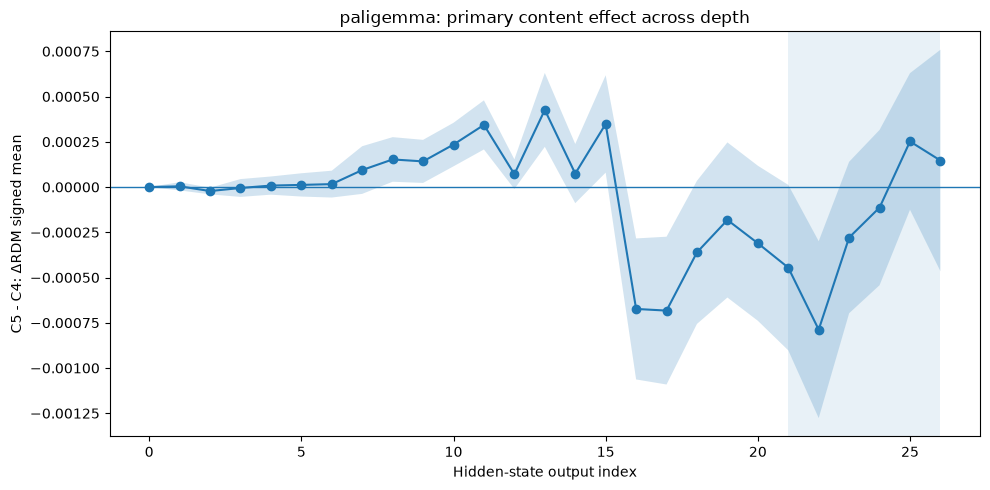

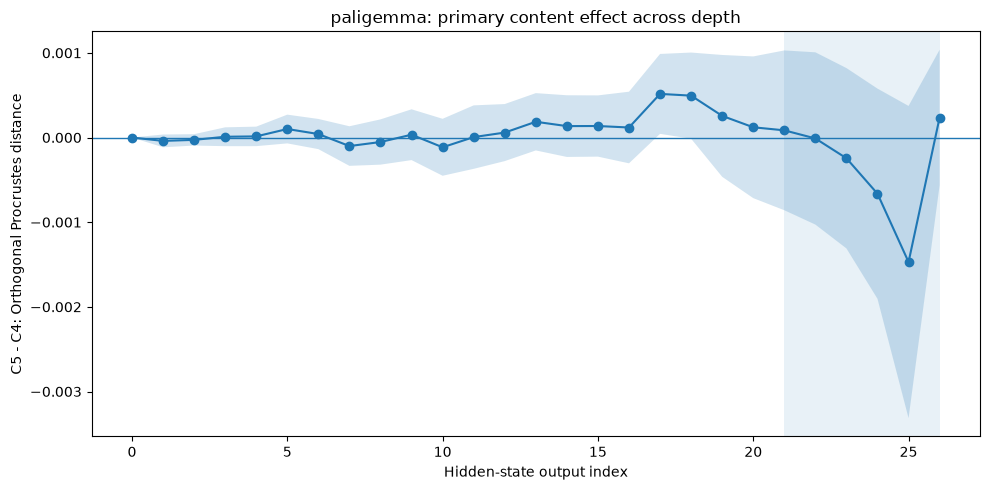

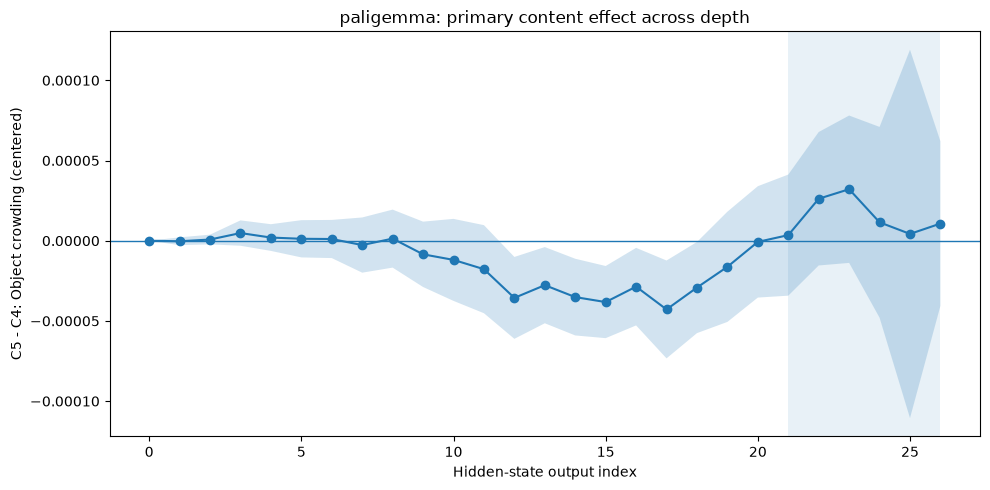

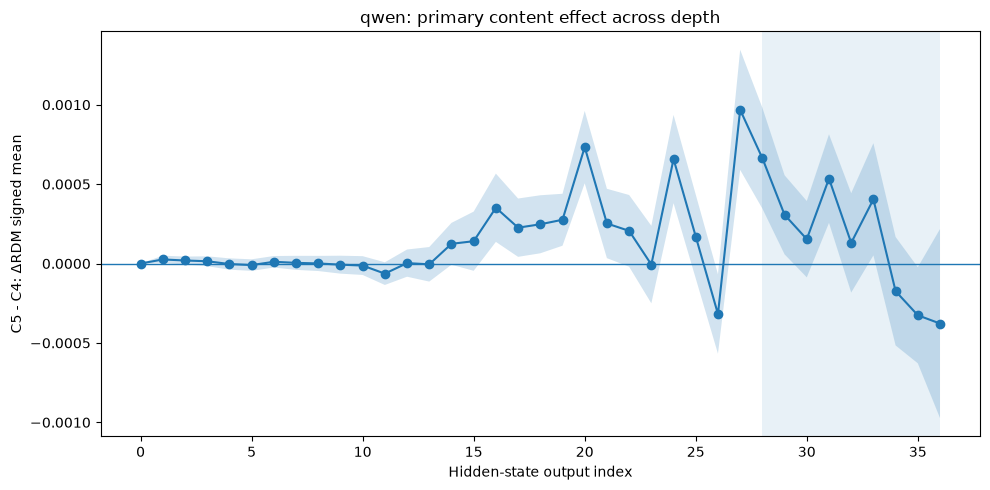

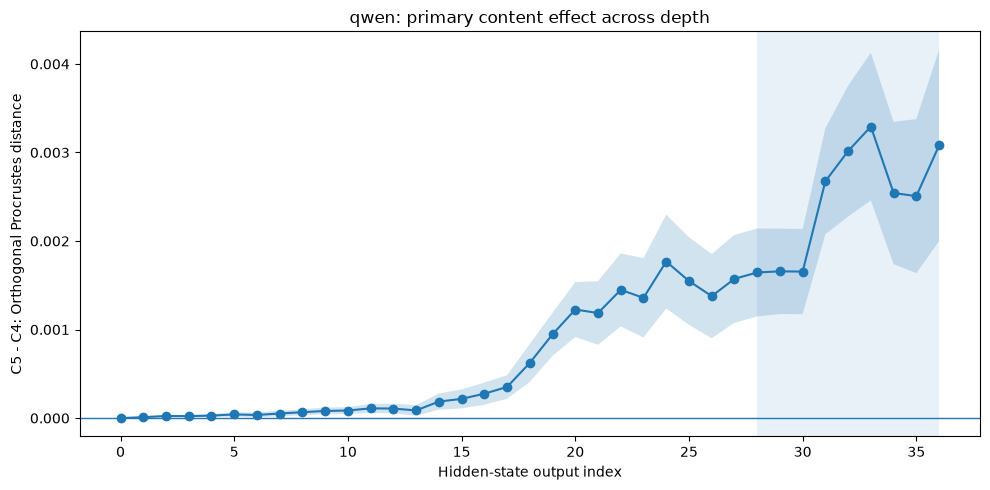

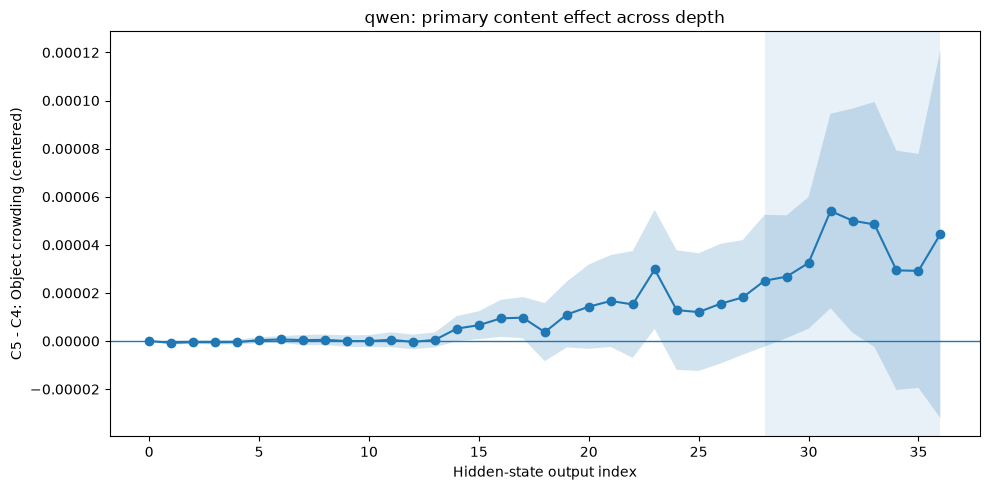

In [42]:
def layer_effect_profile(model_key, suffix, contrast="short_relevance_C5_minus_C4"):
    subset = geometry_results[geometry_results["model"] == model_key]

    rows = []
    for output_index, layer_df in subset.groupby("output_index"):
        by_image = (
            layer_df.groupby(
                ["image_id", "object_count", "num_outputs"],
                as_index=False
            )
            .mean(numeric_only=True)
        )
        values = {c: by_image[f"{c}_{suffix}"] for c in ["c3", "c4", "c5", "c6", "c7", "c8"]}
        effect = CONTRASTS[contrast](values)
        effect = np.asarray(effect, dtype=float)
        effect = effect[np.isfinite(effect)]

        if len(effect) < 2:
            continue

        rows.append({
            "model": model_key,
            "output_index": int(output_index),
            "num_outputs": int(layer_df["num_outputs"].iloc[0]),
            "estimate": float(effect.mean()),
            "se": float(effect.std(ddof=1) / math.sqrt(len(effect))),
            "n_images": int(len(effect)),
        })

    return pd.DataFrame(rows)

for model_key in ["paligemma", "qwen"]:
    for metric_key in ["rdm_signed", "procrustes", "crowding_centered"]:
        prof = layer_effect_profile(model_key, IMAGE_METRICS[metric_key])
        prof.to_csv(
            RESULTS_DIR / f"{model_key}_{metric_key}_layer_profile.csv",
            index=False,
        )

        if len(prof):
            plt.figure(figsize=(10, 5))
            plt.plot(prof["output_index"], prof["estimate"], marker="o")
            plt.fill_between(
                prof["output_index"],
                prof["estimate"] - 1.96 * prof["se"],
                prof["estimate"] + 1.96 * prof["se"],
                alpha=0.2,
            )

            start = min(final_quarter_outputs(int(prof["num_outputs"].iloc[0])))
            end = int(prof["num_outputs"].iloc[0]) - 1
            plt.axvspan(start, end, alpha=0.1)
            plt.axhline(0, linewidth=1)
            plt.xlabel("Hidden-state output index")
            plt.ylabel(f"C5 - C4: {DISPLAY_METRIC[metric_key]}")
            plt.title(f"{model_key}: primary content effect across depth")
            plt.tight_layout()
            plt.savefig(
                FIGURES_DIR / f"{model_key}_{metric_key}_layer_profile.png",
                dpi=180,
            )
            plt.show()


## 30. Primary effect by object count


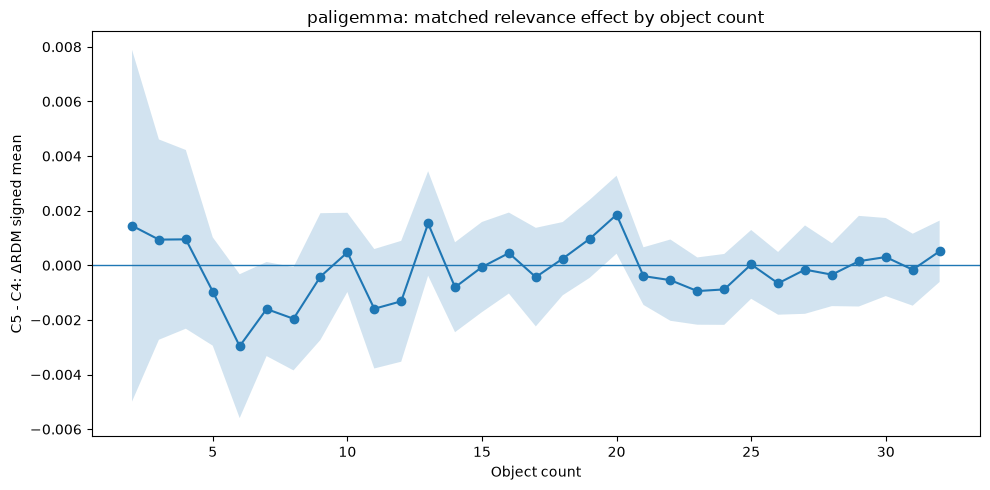

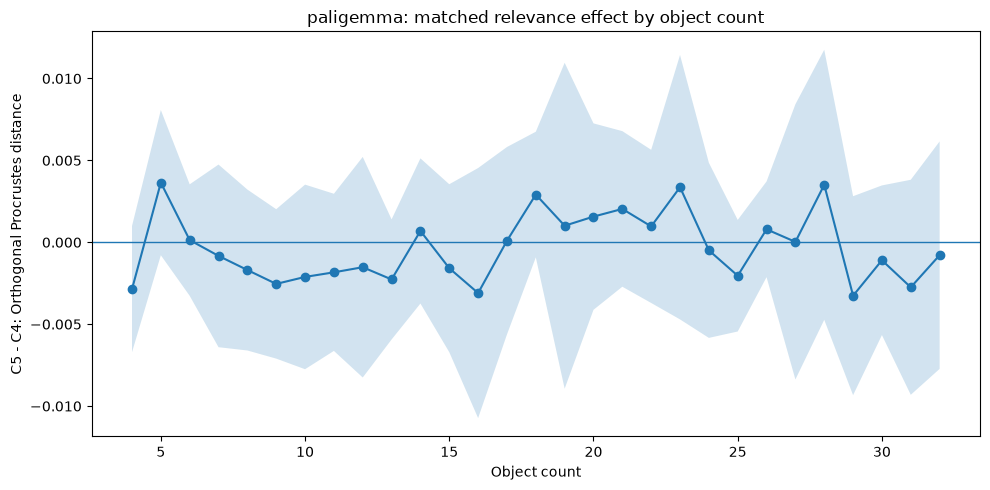

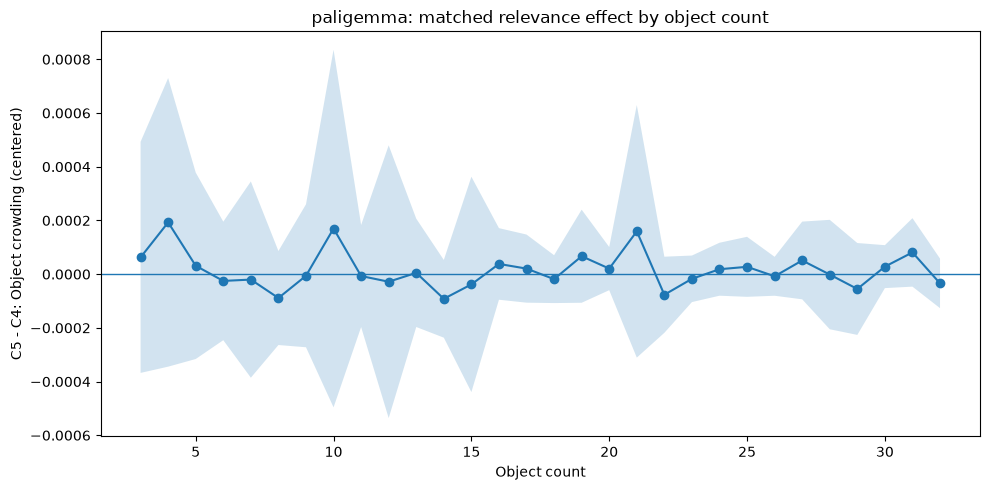

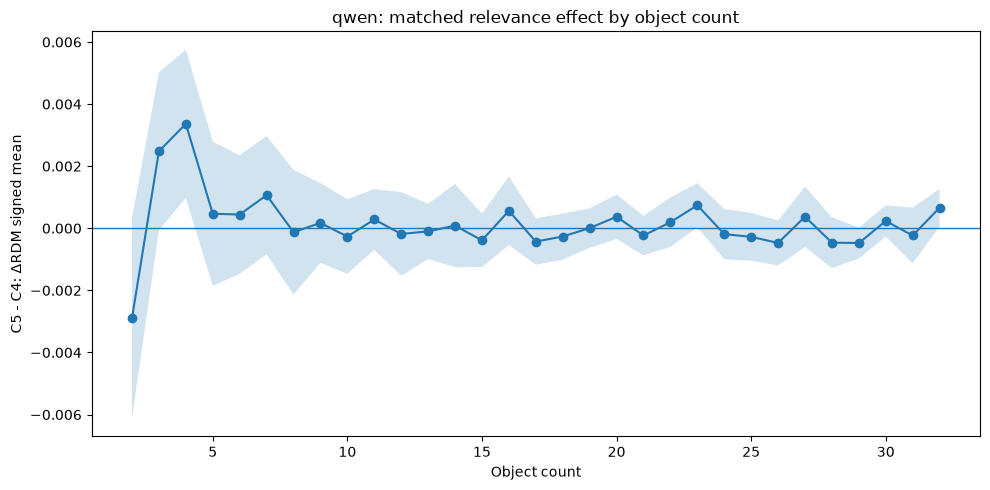

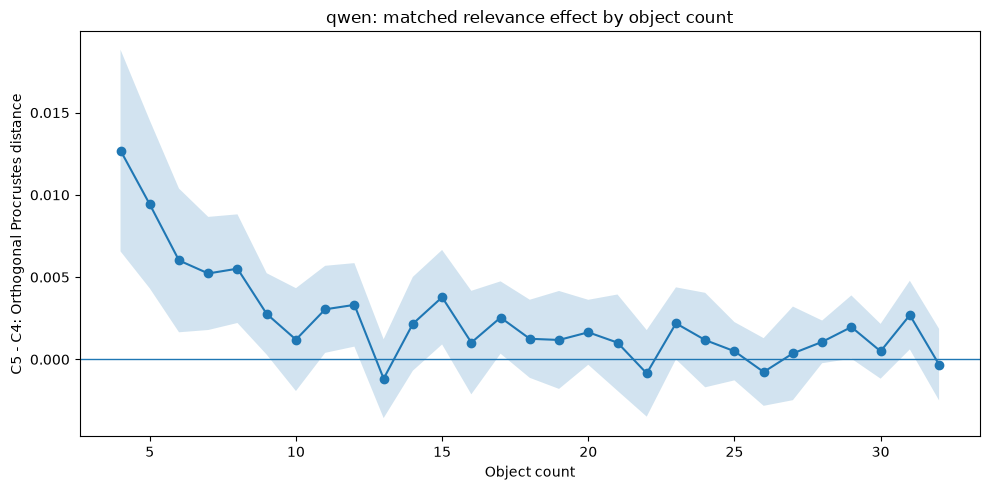

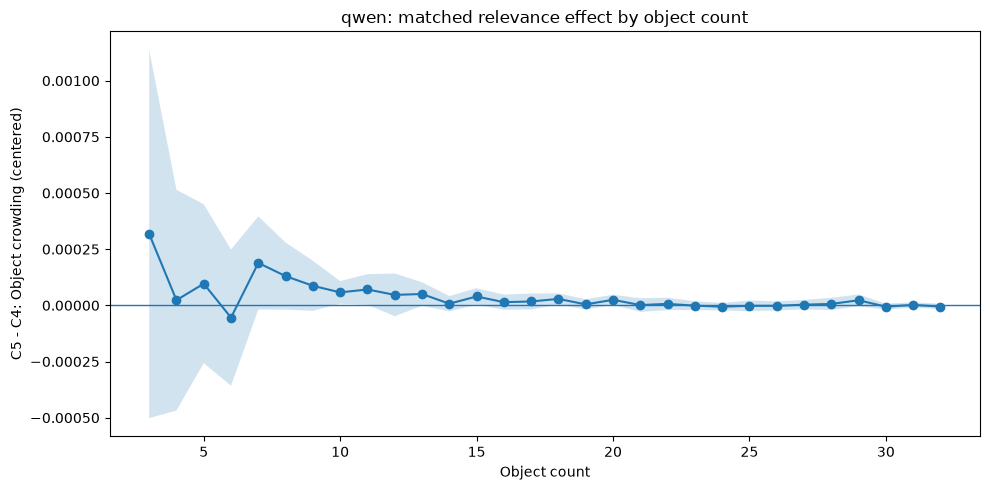

In [43]:
def plot_primary_by_count(model_key, metric_key):
    table = image_effect_tables[(model_key, metric_key)]
    grouped = table.groupby("object_count")["short_relevance_C5_minus_C4"].agg(
        ["mean", "std", "count"]
    )
    grouped["se"] = grouped["std"] / np.sqrt(grouped["count"])

    plt.figure(figsize=(10, 5))
    plt.plot(grouped.index, grouped["mean"], marker="o")
    plt.fill_between(
        grouped.index,
        grouped["mean"] - 1.96 * grouped["se"],
        grouped["mean"] + 1.96 * grouped["se"],
        alpha=0.2,
    )
    plt.axhline(0, linewidth=1)
    plt.xlabel("Object count")
    plt.ylabel(f"C5 - C4: {DISPLAY_METRIC[metric_key]}")
    plt.title(f"{model_key}: matched relevance effect by object count")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"{model_key}_{metric_key}_primary_by_count.png",
        dpi=180,
    )
    plt.show()

for model_key in ["paligemma", "qwen"]:
    for metric_key in ["rdm_signed", "procrustes", "crowding_centered"]:
        plot_primary_by_count(model_key, metric_key)


## 31. Intrinsic-dimension k robustness


In [44]:
id_k_summary = (
    id_results[id_results["is_primary_depth"]]
    .groupby(["model", "object_count", "condition", "k"])["id_mle"]
    .mean()
    .reset_index()
)

id_k_contrast_rows = []
for (model_key, k), group in id_k_summary.groupby(["model", "k"]):
    wide = group.pivot(
        index="object_count",
        columns="condition",
        values="id_mle",
    ).reset_index()

    for contrast_name, fn in CONTRASTS.items():
        vals = {
            c: wide[c]
            for c in ["c3", "c4", "c5", "c6", "c7", "c8"]
        }
        effect = fn(vals)
        id_k_contrast_rows.append({
            "model": model_key,
            "k": int(k),
            "contrast": contrast_name,
            "estimate_across_counts": float(np.nanmean(effect)),
            "positive_count_levels": int(np.nansum(np.asarray(effect) > 0)),
            "negative_count_levels": int(np.nansum(np.asarray(effect) < 0)),
        })

id_k_robustness = pd.DataFrame(id_k_contrast_rows)
id_k_robustness.to_csv(
    RESULTS_DIR / "id_k_robustness.csv", index=False
)

display(
    id_k_robustness[
        id_k_robustness["contrast"] == "short_relevance_C5_minus_C4"
    ]
)


,model,k,contrast,estimate_across_counts,positive_count_levels,negative_count_levels
0,paligemma,3,short_relevance_C5_minus_C4,0.020938,15,16
9,paligemma,5,short_relevance_C5_minus_C4,-0.003908,16,15
18,paligemma,7,short_relevance_C5_minus_C4,0.020949,17,14
27,paligemma,10,short_relevance_C5_minus_C4,0.020554,19,12
36,qwen,3,short_relevance_C5_minus_C4,0.117247,25,6
45,qwen,5,short_relevance_C5_minus_C4,0.170420,29,2
54,qwen,7,short_relevance_C5_minus_C4,0.151562,29,2
63,qwen,10,short_relevance_C5_minus_C4,0.109132,28,3


## 32. Verification checklist

A paper result should only be interpreted after the mechanical controls pass.

**Passing this checklist does not guarantee the scientific hypothesis is true.**  
It only means the final run is complete and the extraction/control machinery behaved as intended.


In [45]:
checks = []

def add_check(name, passed, detail):
    checks.append({
        "check": name,
        "passed": bool(passed),
        "detail": str(detail),
    })

add_check(
    "Exactly 620 unique scenes",
    len(manifest) == EXPECTED_IMAGES == 620,
    len(manifest),
)
add_check(
    "Every object count 2-32 present",
    sorted({r["object_count"] for r in manifest}) == OBJECT_COUNTS,
    sorted({r["object_count"] for r in manifest}),
)
add_check(
    "20 scenes per object count",
    all(sum(r["object_count"] == c for r in manifest) == 20 for c in OBJECT_COUNTS),
    {c: sum(r["object_count"] == c for r in manifest) for c in OBJECT_COUNTS},
)
add_check(
    "Shared prompt plan covers all 620 scenes",
    len(shared_prompt_rows) == EXPECTED_IMAGES,
    len(shared_prompt_rows),
)

add_check(
    "Expanded descriptor vocabulary (72)",
    len(DESCRIPTORS) == 72,
    len(DESCRIPTORS),
)
add_check(
    "Expanded candidate position grid (49)",
    len(GRID_CENTERS) == 49,
    len(GRID_CENTERS),
)
add_check(
    "Stimulus mean overlap below 0.55",
    float(scene_overlap["mean_jaccard"].max()) < 0.55,
    float(scene_overlap["mean_jaccard"].max()),
)
add_check(
    "C4/C7 descriptors disjoint in every scene",
    all(set(r["irrelevant_A_names"]).isdisjoint(set(r["irrelevant_B_names"]))
        for r in shared_prompt_rows),
    "all scenes",
)
add_check(
    "PaliGemma text-influence gate passed",
    bool((pali_text_gate["last_layer_max_abs"] >= 1e-4).all()),
    pali_text_gate["last_layer_max_abs"].tolist(),
)
add_check(
    "Dedicated 3-test confirmatory family computed",
    len(confirmatory_statistics) == 6,
    len(confirmatory_statistics),
)
add_check(
    "Multiple prompt templates used",
    prompt_audit["template_id"].nunique() == len(PROMPT_TEMPLATES),
    sorted(prompt_audit["template_id"].unique().tolist()),
)
add_check(
    "Substantial relevant-prompt diversity",
    prompt_audit["c5"].nunique() >= 100,
    prompt_audit["c5"].nunique(),
)
add_check(
    "PaliGemma all 620 checkpoints present",
    len(pali_vectors) == EXPECTED_IMAGES,
    len(pali_vectors),
)
add_check(
    "Qwen all 620 checkpoints present",
    len(qwen_vectors) == EXPECTED_IMAGES,
    len(qwen_vectors),
)
add_check(
    "Same scene IDs in both models",
    [r["image_id"] for r in pali_vectors] == [r["image_id"] for r in qwen_vectors],
    f"{len(pali_vectors)} paired IDs",
)
add_check(
    "ID uses constant 40-vector pool",
    set(id_results["num_vectors"].unique()) == {ID_POOL_N},
    sorted(id_results["num_vectors"].unique().tolist()),
)
add_check(
    "Layer-0 floor below tolerance",
    float(layer0_floor["max_abs_vector_difference"].max()) <= NULL_TOLERANCE,
    float(layer0_floor["max_abs_vector_difference"].max()),
)
add_check(
    "Qwen image-first null below tolerance",
    np.isfinite(qwen_null_max) and qwen_null_max <= NULL_TOLERANCE,
    qwen_null_max,
)
add_check(
    "Primary statistics computed",
    len(primary_statistics) == 2 * len(PRIMARY_METRICS),
    len(primary_statistics),
)
add_check(
    "Cross-model replication table computed",
    len(cross_model_replication) >= 5,
    len(cross_model_replication),
)
add_check(
    "Within-category negative control computed",
    len(noise_floor_statistics) > 0,
    len(noise_floor_statistics),
)

verification_checklist = pd.DataFrame(checks)
verification_checklist.to_csv(
    RESULTS_DIR / "verification_checklist.csv", index=False
)
display(verification_checklist)

if not verification_checklist["passed"].all():
    warnings.warn(
        "At least one mechanical verification check failed. "
        "Do not write a scientific conclusion until it is inspected."
    )


,check,passed,detail
0,Exactly 620 unique scenes,True,620
1,Every object count 2-32 present,True,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1..."
2,20 scenes per object count,True,"{2: 20, 3: 20, 4: 20, 5: 20, 6: 20, 7: 20, 8: ..."
3,Shared prompt plan covers all 620 scenes,True,620
4,Expanded descriptor vocabulary (72),True,72
5,Expanded candidate position grid (49),True,49
6,Stimulus mean overlap below 0.55,True,0.4856039325084511
7,C4/C7 descriptors disjoint in every scene,True,all scenes
8,PaliGemma text-influence gate passed,True,"[2.098050117492676, 2.616994857788086, 2.16490..."
9,Dedicated 3-test confirmatory family computed,True,6


/tmp/ipykernel_3454/3014293292.py:125: UserWarning: At least one mechanical verification check failed. Do not write a scientific conclusion until it is inspected.
  warnings.warn(


## 33. Paper-facing summary tables


In [46]:
condition_summary_rows = []

for model_key in ["paligemma", "qwen"]:
    g = geometry_results[
        (geometry_results["model"] == model_key)
        & geometry_results["is_primary_depth"]
    ]
    ids = id_results[
        (id_results["model"] == model_key)
        & (id_results["k"] == PRIMARY_ID_K)
        & id_results["is_primary_depth"]
    ]

    for condition in CONDITIONS:
        condition_summary_rows.append({
            "model": model_key,
            "condition": condition,
            "condition_label": CONDITION_LABELS[condition],
            "images": g["image_id"].nunique(),
            "object_count_levels": g["object_count"].nunique(),
            "crowding_centered": float(g[f"{condition}_crowding_centered"].mean()),
            "crowding_uncentered": float(g[f"{condition}_crowding_uncentered"].mean()),
            "anisotropy": float(g[f"{condition}_anisotropy"].mean()),
            "rdm_signed_vs_c2": (
                0.0 if condition == "c2"
                else float(g[f"{condition}_rdm_signed"].mean())
            ),
            "rdm_rmse_vs_c2": (
                0.0 if condition == "c2"
                else float(g[f"{condition}_rdm_rmse"].mean())
            ),
            "procrustes_vs_c2": (
                0.0 if condition == "c2"
                else float(g[f"{condition}_procrustes"].mean())
            ),
            "intrinsic_dimension_mle": float(
                ids[ids["condition"] == condition]["id_mle"].mean()
            ),
        })

condition_summary = pd.DataFrame(condition_summary_rows)
condition_summary.to_csv(
    RESULTS_DIR / "condition_summary.csv", index=False
)

paper_primary = primary_statistics[
    [
        "model", "metric", "unit", "n", "estimate",
        "bootstrap_bca_95_low", "bootstrap_bca_95_high",
        "cohen_dz", "t_p_raw", "holm_p_within_family",
        "significant_holm_0_05", "abs_dz_ge_reference",
    ]
].sort_values(["model", "metric"])

display(paper_primary)
display(cross_model_replication)
display(count_consistency)


,model,metric,unit,n,estimate,bootstrap_bca_95_low,bootstrap_bca_95_high,cohen_dz,t_p_raw,holm_p_within_family,significant_holm_0_05,abs_dz_ge_reference
0,paligemma,ΔRDM signed mean,image,620,-0.000205,-0.000576,0.000189,-0.041961,0.296510,0.296510,False,False
54,qwen,ΔRDM signed mean,image,620,0.000146,-0.000105,0.000395,0.045574,0.256907,0.256907,False,False


,metric,shared_images,paligemma_mean_effect,qwen_mean_effect,same_sign_fraction,effect_correlation,qwen_minus_pali_mean,paired_model_difference_p
0,ΔRDM signed mean,620,-0.000205,0.000146,0.517742,0.024657,0.000351,0.130605
1,ΔRDM RMSE,620,0.000052,0.000366,0.462903,0.020607,0.000313,0.087460
2,Orthogonal Procrustes distance,580,-0.000345,0.002452,0.475862,0.003413,0.002797,0.000007
3,Object crowding (centered),600,0.000015,0.000039,0.496667,-0.009565,0.000024,0.451457
4,Intrinsic dimensionality MLE (k=5),31,-0.003908,0.170420,0.580645,-0.049494,0.174328,0.008128


,model,metric,contrast,count_levels_tested,positive_levels,negative_levels,sign_consistency_fraction,two_sided_binomial_p
0,paligemma,ΔRDM signed mean,short_relevance_C5_minus_C4,31,13,18,0.580645,4.731297e-01
1,paligemma,ΔRDM RMSE,short_relevance_C5_minus_C4,31,16,15,0.516129,1.000000e+00
2,paligemma,Orthogonal Procrustes distance,short_relevance_C5_minus_C4,29,13,16,0.551724,7.110711e-01
3,paligemma,Object crowding (centered),short_relevance_C5_minus_C4,30,15,15,0.500000,1.000000e+00
4,qwen,ΔRDM signed mean,short_relevance_C5_minus_C4,31,16,15,0.516129,1.000000e+00
5,qwen,ΔRDM RMSE,short_relevance_C5_minus_C4,31,21,10,0.677419,7.075555e-02
6,qwen,Orthogonal Procrustes distance,short_relevance_C5_minus_C4,29,25,4,0.862069,1.037158e-04
7,qwen,Object crowding (centered),short_relevance_C5_minus_C4,30,23,7,0.766667,5.222879e-03
8,paligemma,Intrinsic dimensionality MLE (k=5),short_relevance_C5_minus_C4,31,16,15,0.516129,1.000000e+00
9,qwen,Intrinsic dimensionality MLE (k=5),short_relevance_C5_minus_C4,31,29,2,0.935484,4.628673e-07


## 34. Export all paper-ready results

The Excel/CSV archive contains summary/statistical outputs and prompt/data manifests.  
The multi-GB representation checkpoints remain on the instance disk unless you explicitly copy them.

**Do not terminate Lambda until the archive has been downloaded.**


In [47]:
OUTPUT_XLSX = RESULTS_DIR / "experiment3_FINAL_quality_620x620_results.xlsx"

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
    confirmatory_statistics.to_excel(writer, sheet_name="CONFIRMATORY", index=False)
    paper_primary.to_excel(writer, sheet_name="Legacy Primary", index=False)
    statistics_table.to_excel(writer, sheet_name="All Statistics", index=False)
    condition_summary.to_excel(writer, sheet_name="Condition Summary", index=False)
    noise_floor_statistics.to_excel(writer, sheet_name="Noise Floor", index=False)
    cross_model_replication.to_excel(writer, sheet_name="Cross Model", index=False)
    count_consistency.to_excel(writer, sheet_name="Count Consistency", index=False)
    moderation_results.to_excel(writer, sheet_name="Count Moderation", index=False)
    mixed_model_results.to_excel(writer, sheet_name="Mixed Models", index=False)
    id_k_robustness.to_excel(writer, sheet_name="ID k Robustness", index=False)
    procrustes_null.to_excel(writer, sheet_name="Procrustes Null", index=False)
    layer0_floor.to_excel(writer, sheet_name="Embedding Floor", index=False)
    qwen_architecture_null.to_excel(writer, sheet_name="Qwen Causal Null", index=False)
    prompt_audit.to_excel(writer, sheet_name="Prompt Audit", index=False)
    dataset_integrity.to_excel(writer, sheet_name="Dataset Integrity", index=False)
    scene_overlap.to_excel(writer, sheet_name="Scene Overlap", index=False)
    verification_checklist.to_excel(writer, sheet_name="Verification", index=False)

final_manifest = {
    "run_name": RUN_NAME,
    "unique_scenes": len(manifest),
    "images_per_count": N_IMAGES_PER_COUNT,
    "object_counts": OBJECT_COUNTS,
    "paligemma_images": len(pali_vectors),
    "qwen_images": len(qwen_vectors),
    "same_scene_ids_across_models": (
        [r["image_id"] for r in pali_vectors]
        == [r["image_id"] for r in qwen_vectors]
    ),
    "primary_model": PRIMARY_MODEL_ID,
    "secondary_model": SECONDARY_MODEL_ID,
    "conditions": CONDITION_LABELS,
    "primary_contrast": "C5 - C4 (short relevant - short matched irrelevant A)",
    "negative_control": "C7 - C4 and direct C4->C7 prompt-change noise floor",
    "all_mechanical_checks_passed": bool(verification_checklist["passed"].all()),
    "id_design": {
        "objects_per_image": ID_OBJECTS_PER_IMAGE,
        "images_per_count": N_IMAGES_PER_COUNT,
        "vectors_per_count_cell": ID_POOL_N,
        "repeats": ID_REPEATS,
        "primary_k": PRIMARY_ID_K,
        "k_values": ID_K_VALUES,
    },
    "important_note": (
        "Final run uses vocabulary-matched absent-object irrelevant prompts. "
        "Do not pool these estimates with the earlier abstract-irrelevant pilot."
    ),
}

(RESULTS_DIR / "final_run_manifest.json").write_text(
    json.dumps(final_manifest, indent=2),
    encoding="utf-8",
)

EXPORT_PATH = Path.home() / "experiment3_FINAL_quality_620x620_paper_ready.tar.gz"

with tarfile.open(EXPORT_PATH, "w:gz") as tar:
    for path in [
        RESULTS_DIR,
        PROMPTS_DIR,
        MANIFEST_PATH,
        ROOT / "run_config.json",
        ROOT / "model_revisions.json",
        ROOT / "reproducibility_metadata.json",
        PROGRESS_FILE,
    ]:
        path = Path(path)
        if path.exists():
            tar.add(path, arcname=path.relative_to(ROOT))

print("Saved Excel:", OUTPUT_XLSX)
print("Saved manifest:", RESULTS_DIR / "final_run_manifest.json")
print("Paper-ready archive:", EXPORT_PATH)
print("Raw vector checkpoints:", VECTORS_DIR)
print("\nDO NOT TERMINATE THE LAMBDA INSTANCE until you download the archive.")


Saved Excel: /home/ubuntu/ESSR/experiment3_FINAL_REVIEWER_FIXED_620x620_seed20260730_v2/results/experiment3_FINAL_quality_620x620_results.xlsx
Saved manifest: /home/ubuntu/ESSR/experiment3_FINAL_REVIEWER_FIXED_620x620_seed20260730_v2/results/final_run_manifest.json
Paper-ready archive: /home/ubuntu/experiment3_FINAL_quality_620x620_paper_ready.tar.gz
Raw vector checkpoints: /home/ubuntu/ESSR/experiment3_FINAL_REVIEWER_FIXED_620x620_seed20260730_v2/vectors

DO NOT TERMINATE THE LAMBDA INSTANCE until you download the archive.


## 35. Final checkpoint status


In [48]:
print("Progress:", load_progress())
print("PaliGemma files:", len(list(PALIGEMMA_VECTOR_DIR.glob("*.npz"))), "/", EXPECTED_IMAGES)
print("Qwen files:", len(list(QWEN_VECTOR_DIR.glob("*.npz"))), "/", EXPECTED_IMAGES)
print("Qwen null files:", len(list(QWEN_NULL_DIR.glob("*.npz"))))
print("Results directory:", RESULTS_DIR)


Progress: {'stage': 'qwen', 'completed': 620, 'total': 620, 'updated_unix': 1788555594.4515293, 'elapsed_seconds_this_session': 755.966598033905}
PaliGemma files: 620 / 620
Qwen files: 620 / 620
Qwen null files: 15
Results directory: /home/ubuntu/ESSR/experiment3_FINAL_REVIEWER_FIXED_620x620_seed20260730_v2/results
